# Chatbot conversacional con RAG sobre Mundiales de fútbol (1930–2026)

Trabajo de NLP, Maestría en Inteligencia Artificial Aplicada. Parte de la guía `2-ollama-langchain.ipynb`
(LangChain, Ollama y FAISS) y del paper de RAG de Lewis et al. (2020), y lo lleva a un caso propio: preguntas en
español sobre partidos, plantillas y artículos de Wikipedia de los Mundiales, con énfasis en Colombia.

**Tiempos de ejecución.** La suma de las etapas que cronometra `crono` (arranque de Ollama, índices, evaluación y
generación) fue de 8,5 min en la ejecución completa sobre una T4, y de 1,1 min en una ejecución de prueba anterior con
`SMOKE_TEST = True`. Esas cifras no incluyen la instalación de dependencias, la descarga de datos y modelos ni el análisis
exploratorio, de modo que el tiempo total de punta a punta no está medido.

**Cómo ejecutarlo.** Se requiere un entorno de Colab con GPU T4. La primera pasada debe hacerse con
`SMOKE_TEST = True` en la celda de configuración: recorre todo el flujo con un subconjunto pequeño y deja ver los
errores en minutos. Una vez validada, se cambia a `False` para la ejecución completa.

**Contenido:** Contexto (problema y motivación) · 1 Instalación e importaciones · 2 Entorno · 3 Datos · 4 EDA ·
5 Índice y pipeline base · 6 Chat conversacional · 7 Evaluación y experimentos · 8 Resultados · 9 Demos ·
10 Conclusiones y limitaciones.

**Fuentes y licencias.** Partidos y plantillas: [openfootball/worldcup](https://github.com/openfootball/worldcup)
(CC0; las carpetas `wikipedia/` y `rsssf/` son conversiones de páginas de terceros). Artículos: Wikipedia en español
(CC BY-SA). Paper: Lewis et al., *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*, 2020.

## Contexto: problema y motivación

Los modelos de lenguaje pequeños, como `llama3.2:3b`, responden con soltura pero fallan en datos puntuales:
marcadores, alineaciones o fechas de un partido concreto. En un dominio como los Mundiales, donde una respuesta solo es
correcta si coincide con el registro, ese es el error más costoso. Lewis et al. (2020) proponen combinar la memoria
paramétrica del modelo con una memoria no paramétrica, un índice de documentos que se consulta al responder. En su
evaluación humana de generación de preguntas tipo Jeopardy (Tabla 4), RAG fue más factual que BART en el 42,7 % de los
casos, frente a un 7,1 % en que BART resultó mejor.

Se eligieron los Mundiales, con énfasis en Colombia, por tres razones. Los datos son verificables: marcadores,
alineaciones y plantillas de 23 ediciones. La consulta es en español pero las fuentes principales están en inglés, lo
que justifica un modelo de embeddings multilingüe. Y el dominio mezcla datos estructurados con texto narrativo
(artículos de Wikipedia), de modo que hay que recuperar tanto nombres y marcadores como explicaciones.

El paper también orienta uno de los experimentos. En su Tabla 6, el recuperador aprendido supera claramente a BM25 en
preguntas abiertas (NQ, RAG-Token: 43,5 frente a 29,7 de exact match), mientras que en FEVER, una tarea centrada en
entidades, BM25 queda ligeramente por delante (FEVER-3: 75,1 frente a 74,5). Como este corpus abunda en nombres y
marcadores, se comparan recuperación densa, BM25 e híbrida. Esa comparación del paper enfrenta un recuperador entrenado
con BM25 dentro de un mismo modelo; aquí solo sirve de motivación, no de resultado esperado.

Se trata de un chatbot conversacional con RAG (modelo de lenguaje, conocimiento recuperado, memoria e interfaz), no de
un ChatGPT: el modelo es pequeño y responde únicamente con el corpus indexado.

**Qué se corrigió respecto a la guía**

| Guía | Este notebook |
|---|---|
| Indexa documentos enteros | Fragmentos con metadatos: partido, plantilla y Wikipedia |
| Recupera la fuente con `texts.index(...)` | Las fuentes salen de los metadatos del `Document` |
| e5 sin prefijos `query:` / `passage:` | Prefijos aplicados y efecto medido |
| Ollama lanzado a mano con `%xterm` | `subprocess` y `ollama pull` |
| `faiss-gpu-cu12` | `faiss-cpu` (sobra para unos miles de vectores) |
| Sin evaluación | Recall@k, MRR, latencia y exactitud de respuesta |
| Sin comparación con y sin RAG | Mismas preguntas con y sin contexto |
| Solo recuperación densa | Además BM25 e híbrido, memoria con reformulación y validaciones de datos |

## 1. Instalación e importaciones

Primera celda de código del notebook: instala las dependencias con versión fija (solo en Colab) y reúne todas las
importaciones, que no se repiten en ningún otro lugar.

In [ ]:
import subprocess
import sys

DEPENDENCIAS = ["langchain-core==1.6.6", "langchain-community==0.4.2", "langchain-ollama==1.1.0",
                "langchain-text-splitters==1.1.3", "faiss-cpu==1.15.1", "sentence-transformers==6.1.0",
                "rank-bm25==0.2.2", "gradio==6.29.1"]
if "google.colab" in sys.modules:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *DEPENDENCIAS])

import collections
import copy
import hashlib
import json
import os
import random
import re
import statistics
import time
import unicodedata
import warnings
import zipfile
from collections import Counter, defaultdict
from contextlib import contextmanager
from dataclasses import dataclass
from datetime import date
from pathlib import Path
from time import perf_counter

import gradio as gr
import httpx
import matplotlib.pyplot as plt
import numpy as np
import ollama
import pandas as pd
import requests
import torch
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_core.documents import Document
from langchain_core.embeddings import Embeddings
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from langchain_text_splitters import RecursiveCharacterTextSplitter
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
from transformers import AutoTokenizer

try:
    from google.colab import drive
except ImportError:  # fuera de Colab
    drive = None

warnings.filterwarnings("ignore")

/tmp/ipykernel_7945/236029147.py:37: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


### Esquema del pipeline

Resumen visual del flujo que se construye en las secciones siguientes. Se ubica aquí porque dibujarlo requiere las
librerías importadas en la celda anterior.

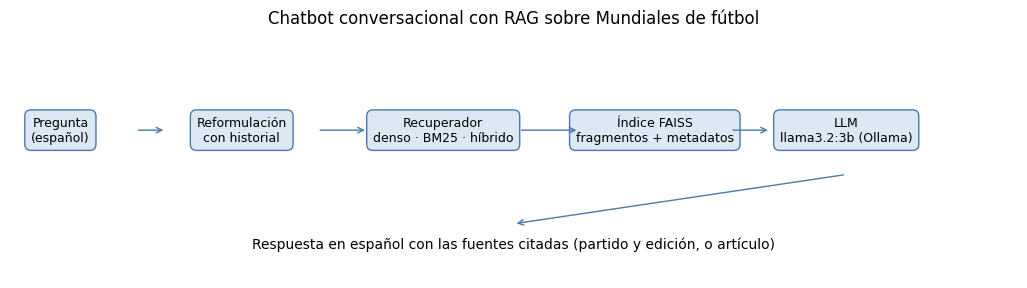

In [ ]:
# Esquema del pipeline
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.axis("off")
cajas = [("Pregunta\n(español)", 0.05), ("Reformulación\ncon historial", 0.23), ("Recuperador\ndenso · BM25 · híbrido", 0.43),
         ("Índice FAISS\nfragmentos + metadatos", 0.64), ("LLM\nllama3.2:3b (Ollama)", 0.83)]
for texto, x in cajas:
    ax.text(x, 0.6, texto, ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.5", fc="#DCE9F5", ec="#4C78A8"))
for (_, x0), (_, x1) in zip(cajas, cajas[1:]):
    ax.annotate("", xy=(x1 - 0.075, 0.6), xytext=(x0 + 0.075, 0.6), arrowprops=dict(arrowstyle="->", color="#4C78A8"))
ax.text(0.5, 0.12, "Respuesta en español con las fuentes citadas (partido y edición, o artículo)", ha="center", fontsize=10)
ax.annotate("", xy=(0.5, 0.22), xytext=(0.83, 0.42), arrowprops=dict(arrowstyle="->", color="#4C78A8"))
ax.set_title("Chatbot conversacional con RAG sobre Mundiales de fútbol")
plt.show()

## 2. Entorno

La configuración centraliza las opciones de ejecución. Ollama se lanza con `subprocess`, sin terminal interactiva.

### Configuración

`SMOKE_TEST = True` usa un subconjunto pequeño del corpus (todo lo de Colombia más una muestra al azar), menos
preguntas y sus propios índices (con sufijo `_humo`, que nunca se mezclan con los completos). Sirve para detectar
errores en minutos; **sus resultados no son los finales**. Cada configuración de índice se guarda en su propio
directorio, así que una segunda ejecución reutiliza lo ya calculado. `REBUILD_INDEX = True` fuerza la reconstrucción.

In [ ]:
SMOKE_TEST = False        # True: prueba rápida con subconjunto. False: ejecución completa.
REBUILD_INDEX = False    # True: reconstruye los índices aunque existan en disco.
USAR_DRIVE = False       # True: guarda datos e índices en Google Drive (sobreviven al reinicio del entorno).
SEMILLA = 42

MODELO_LLM = "llama3.2:3b"
MODELO_EMBEDDINGS = "intfloat/multilingual-e5-large"
CONFIGURACIONES = [(MODELO_EMBEDDINGS, True), (MODELO_EMBEDDINGS, False)]  # (modelo, prefijos); un índice por cada una
KS_GENERACION = (3, 5, 10)

if USAR_DRIVE:
    drive.mount("/content/drive")
    RAIZ = Path("/content/drive/MyDrive/mundial_bot")
else:
    RAIZ = Path("mundial_bot")
REPO = RAIZ / "worldcup"
DIR_WIKIPEDIA = RAIZ / "data" / "wikipedia"
DIR_INDICES = RAIZ / "indices"
RAIZ.mkdir(parents=True, exist_ok=True)

if SMOKE_TEST:
    print("MODO PRUEBA RÁPIDA (SMOKE_TEST = True): los resultados de este notebook NO son los finales.")

In [ ]:
OLLAMA_URL = "http://localhost:11434"


def fija_semillas(semilla=42):
    random.seed(semilla)
    np.random.seed(semilla)
    os.environ["PYTHONHASHSEED"] = str(semilla)


def ollama_activo():
    try:
        return requests.get(OLLAMA_URL, timeout=2).ok
    except requests.RequestException:
        return False


def inicia_ollama(modelo, descargar=True, espera_max=60):
    """Lanza `ollama serve` si no está activo, espera a que responda y descarga el modelo."""
    if not ollama_activo():
        subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        t0 = time.time()
        while not ollama_activo():
            if time.time() - t0 > espera_max:
                raise RuntimeError(f"Ollama no respondió en {espera_max} s")
            time.sleep(1)
    if descargar:
        subprocess.run(["ollama", "pull", modelo], check=True)


class Cronometro:
    """Acumula el tiempo de cada etapa; el resumen es la medición real del tiempo total del notebook."""

    def __init__(self):
        self.tiempos = {}

    @contextmanager
    def etapa(self, nombre):
        t0 = time.perf_counter()
        try:
            yield
        finally:
            self.tiempos[nombre] = self.tiempos.get(nombre, 0) + time.perf_counter() - t0

    def resumen(self):
        df = pd.DataFrame({"etapa": list(self.tiempos), "segundos": list(self.tiempos.values())})
        df["minutos"] = df["segundos"] / 60
        total = pd.DataFrame([{"etapa": "TOTAL", "segundos": df["segundos"].sum(), "minutos": df["minutos"].sum()}])
        return pd.concat([df, total], ignore_index=True)

In [ ]:
fija_semillas(SEMILLA)
crono = Cronometro()
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {dispositivo}" + (f" ({torch.cuda.get_device_name(0)})" if dispositivo == "cuda" else ""))
if dispositivo == "cpu":
    print("Aviso: sin GPU el índice completo tarda del orden de una hora; use SMOKE_TEST o active la GPU T4.")

Dispositivo: cuda (Tesla T4)


In [ ]:
# Ollama: instalación (solo la primera vez en Colab), arranque con subprocess y descarga del modelo
if subprocess.run("which ollama", shell=True, capture_output=True).returncode != 0:
    subprocess.run("apt-get install -y -q zstd && curl -fsSL https://ollama.com/install.sh | sh", shell=True, check=True)
with crono.etapa("Ollama: arranque y descarga del modelo"):
    inicia_ollama(MODELO_LLM)


TIMEOUT_LLM_S = 120  # segundos sin recibir nada del servidor (la respuesta llega por trozos); no limita la duración total
NUM_PREDICT = 512    # tope de tokens por respuesta: evita que el modelo se quede generando sin parar


def crea_llm():
    return ChatOllama(model=MODELO_LLM, temperature=0, seed=SEMILLA, num_ctx=8192, validate_model_on_init=True,
                      num_predict=NUM_PREDICT, client_kwargs={"timeout": TIMEOUT_LLM_S})


def asegura_ollama():
    """Llamada mínima al servidor de Ollama; si no responde, lo relanza y recrea `llm`."""
    global llm
    if not ollama_activo():
        print("Ollama no responde: se relanza el servidor.")
        inicia_ollama(MODELO_LLM)
        llm = crea_llm()
    return llm


llm = crea_llm()

Se fijó `temperature=0` y la semilla para que las respuestas sean reproducibles, y `num_ctx=8192` porque el contexto por
defecto de Ollama es más corto que los fragmentos recuperados con k = 10 y los truncaría sin avisar. `num_predict=512` limita
los tokens de cada respuesta, para que una generación que no termina (repetición) no bloquee la celda; el timeout de 120 s
solo cubre el silencio del servidor, porque la respuesta llega por trozos. `asegura_ollama()` comprueba que el servidor responda y, si se cayó, lo relanza y recrea `llm`.
Se invoca antes de cada experimento de generación y antes de crear la interfaz.

## 3. Datos

El núcleo del corpus es `openfootball/worldcup`: marcadores de 1930 a 2026 (`cup.txt` y `cup_finals.txt`), los mismos
partidos con goleadores y alineaciones en `wikipedia/{año}.txt` (1930–2022, sin 2026) y las plantillas en
`more/{año}_squads.txt`. Se ignoran `more/{año}.txt`, `more/{año}_full.txt`, `min/`, `rsssf/` y `planetworldcup/`, que
duplican información.

El formato tiene varias disposiciones del marcador (`A v B 3-1 (1-1)`, `A 4-1 (3-0) B`, y en eliminatorias
`A 1-1 a.e.t. (1-1, 0-1), 3-4 pen. B`), una cuarta con los penales antes del tiempo extra (Suiza–Ucrania, 2006), fechas
escritas de varias maneras, goleadores en la línea siguiente y encabezados de fase que cambian de una edición a otra. El
analizador se escribió para todas las ediciones y se valida a continuación con conteos y controles cruzados.

In [ ]:
if not REPO.exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/openfootball/worldcup", str(REPO)], check=True)
commit = subprocess.run(["git", "-C", str(REPO), "log", "-1", "--format=%h %ad"], capture_output=True, text=True).stdout.strip()
print("openfootball/worldcup, último commit:", commit)

openfootball/worldcup, último commit: 1915596 Sat Aug 22 20:08:26 2026 +0200


In [ ]:
ANIOS = [1930, 1934, 1938] + list(range(1950, 2027, 4))


MESES = {m: i for i, m in enumerate(
    ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"], 1)}


CANON = {"USA": "United States", "Ireland": "Republic of Ireland", "Côte d'Ivoire": "Ivory Coast",
         "Bosnia-Herzegovina": "Bosnia and Herzegovina", "Congo DR": "DR Congo", "Czechia": "Czech Republic", "Bosnia & Herzegovina": "Bosnia and Herzegovina",
         "Cabo Verde": "Cape Verde", "Türkiye": "Turkey"}


def canon(nombre):
    return CANON.get(nombre.strip(), nombre.strip())


MES_RE = (r"(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|Jun(?:e)?|Jul(?:y)?|"
          r"Aug(?:ust)?|Sep(?:t(?:ember)?)?|Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)")


FASES = {
    "quarterfinals": "Quarter-finals", "quarter-final": "Quarter-finals",
    "semifinals": "Semi-finals", "semi-final": "Semi-finals",
    "third place match": "Third place", "third-place match": "Third place",
    "match for third place": "Third place", "third-place play-off": "Third place",
    "third place play-off": "Third place",
}


def normaliza_fase(texto):
    t = re.sub(r"^▪+\s*", "", texto).split("|")[0].strip()
    t = re.sub(r"^Group stage,\s*", "", t)
    replay = bool(re.search(r"replays?$", t, flags=re.I))
    t = re.sub(r"\s*[-,]\s*Replays?$", "", t, flags=re.I).strip()
    t = FASES.get(t.lower(), t)
    return f"{t} (replay)" if replay else t


def parsea_fecha(texto, anio):
    """Busca mes y día en textos como 'Wed Jun 10 1998', '30 May' o 'July 13'."""
    m = re.search(r"\b(\d{1,2})\s+([A-Za-z]{3,9})\b", texto)
    if m and m.group(2)[:3].lower() in MESES:
        dia, mes = int(m.group(1)), MESES[m.group(2)[:3].lower()]
    else:
        m = re.search(r"\b([A-Za-z]{3,9})\s+(\d{1,2})\b", texto)
        if not m or m.group(1)[:3].lower() not in MESES:
            return None
        dia, mes = int(m.group(2)), MESES[m.group(1)[:3].lower()]
    return date(anio, mes, dia).isoformat()


PEN_PRIMERO = re.compile(  # 'Switzerland 0-3 pen. 0-0 a.e.t. (0-0) Ukraine'
    r"(?P<pa>\d+)-(?P<pb>\d+)\s+pen\.\s+(?P<a>\d+)-(?P<b>\d+)(?P<aet>\s+a\.e\.t\.?)?"
    r"(?:\s*\((?P<par>\d+-\d+(?:\s*,\s*\d+-\d+)?)\))?"
)


SCORE = re.compile(
    r"(?P<a>\d+)-(?P<b>\d+)"
    r"(?P<aet>\s+a\.e\.t\.?)?"
    r"(?:\s*\((?P<par>\d+-\d+(?:\s*,\s*\d+-\d+)?)\))?"
    r"(?:\s*,?\s*(?P<pa>\d+)-(?P<pb>\d+)\s+pen\.)?"
)


def busca_marcador(texto):
    return PEN_PRIMERO.search(texto) or SCORE.search(texto)


def parsea_marcador(m):
    par = [p.strip() for p in m.group("par").split(",")] if m.group("par") else []
    return {
        "goles_a": int(m.group("a")), "goles_b": int(m.group("b")),
        "prorroga": bool(m.group("aet")),
        "descanso": par[-1] if par else None,
        "penales": f"{m.group('pa')}-{m.group('pb')}" if m.group("pa") else None,
    }


def limpia_goleadores(txt):
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt[1:-1].strip() if txt.startswith("(") and txt.endswith(")") else txt


def lee_goleadores(lineas, i):
    """Si lineas[i] abre un paréntesis de goleadores, lo lee completo. Devuelve (texto, siguiente_i)."""
    if i >= len(lineas) or not lineas[i].strip().startswith("("):
        return None, i
    partes, prof = [], 0
    while i < len(lineas):
        partes.append(lineas[i].strip())
        prof += lineas[i].count("(") - lineas[i].count(")")
        i += 1
        if prof <= 0:
            break
    return limpia_goleadores(" ".join(partes)), i

In [ ]:
PREFIJO = re.compile(
    r"^\s*(?:\((?P<num>\d+)\)\s*)?"
    r"(?:(?P<hora>\d{1,2}:\d{2}(?:\s+UTC[+-]\d+)?)\s+)?"
)


FECHA_SUELTA = re.compile(r"^\s*(?:[A-Za-z]{3}\s+)?(?:\d{1,2}\s+[A-Za-z]{3,9}|[A-Za-z]{3,9}\s+\d{1,2})\s*$")


def carpeta_edicion(anio):
    return next(REPO.glob(f"{anio}--*"))


def parsea_cup(anio):
    partidos = []
    carpeta = carpeta_edicion(anio)
    for nombre in ("cup.txt", "cup_finals.txt"):
        ruta = carpeta / nombre
        if not ruta.exists():
            continue
        crudas = ruta.read_text(encoding="utf-8").splitlines()
        lineas = [re.sub(r"\s#.*$", "", l).rstrip() for l in crudas]  # quita '#' y '##'
        fase, fecha, i = None, None, 0
        while i < len(lineas):
            l = lineas[i]
            if l.startswith("▪"):
                if "|" not in l:
                    fase = normaliza_fase(l)
                i += 1
                continue
            if "@" in l and re.search(r"\d+-\d+", l):
                izq, _, estadio = l.partition("@")
                pref = PREFIJO.match(izq)
                resto = izq[pref.end():]
                # fecha al inicio de la línea (1962: '30 May    Uruguay ...')
                f_inline = re.match(
                    rf"^((?:[A-Za-z]{{3}}\s+)?(?:\d{{1,2}}\s+{MES_RE}|{MES_RE}\s+\d{{1,2}}))"
                    r"(?:\s+(?P<h>\d{1,2}:\d{2}))?\s+", resto)
                hora = pref.group("hora")
                if f_inline:
                    fecha = parsea_fecha(f_inline.group(1), anio)
                    hora = f_inline.group("h") or hora
                    resto = resto[f_inline.end():]
                m = busca_marcador(resto)
                izq_m, der_m = resto[:m.start()].strip(), resto[m.end():].strip()
                if der_m == "" and " v " in izq_m:  # disposición 'A v B 3-1 (1-1)'
                    eq_a, eq_b = (x.strip() for x in izq_m.split(" v ", 1))
                else:
                    eq_a, eq_b = re.sub(r"\s+v$", "", izq_m), der_m
                eq_a, eq_b = canon(eq_a), canon(eq_b)
                inicio = i + 1
                goles, i = lee_goleadores(lineas, i + 1)
                p = {
                    "edicion": anio, "fase": fase, "fecha": fecha,
                    "equipo_a": eq_a, "equipo_b": eq_b,
                    "estadio": estadio.strip(), "hora": hora,
                    "numero": int(pref.group("num")) if pref.group("num") else None,
                    "goleadores": goles, "fuente": f"{ruta.relative_to(REPO).as_posix()}:{inicio}",
                }
                p.update(parsea_marcador(m))
                partidos.append(p)
                continue
            if "@" not in l and FECHA_SUELTA.match(l):
                fecha = parsea_fecha(l, anio) or fecha
            elif re.match(r"^\s*[A-Za-z]{3}\s+[A-Za-z]{3,9}\s+\d{1,2}\s*$", l):
                fecha = parsea_fecha(l, anio) or fecha
            i += 1
    return partidos

In [ ]:
CAB_WIKI = re.compile(r"^(?P<fecha>[A-Z][a-z]{2}\s+[A-Za-z]{3,9}\s+\d{1,2}(?:\s+\d{4})?)\s+@\s+(?P<lugar>.+)$")


MARC_WIKI = re.compile(r"^\s+(?P<a>.+?) v (?P<b>.+?)\s{2}(?P<m>\d+-\d+.*)$")


LINEA_EQUIPO = re.compile(r"^(?P<eq>[^\s:][^:]{0,40}):\s+(?P<resto>\S.*)$")


def parsea_wiki(anio):
    ruta = REPO / "wikipedia" / f"{anio}.txt"
    lineas = [re.sub(r"\s##.*$", "", l).rstrip() for l in ruta.read_text(encoding="utf-8").splitlines()]
    partidos, fase, i = [], None, 0
    while i < len(lineas):
        l = lineas[i]
        if l.startswith("▪"):
            fase = normaliza_fase(l)
            i += 1
            continue
        cab = CAB_WIKI.match(l)
        if not cab or i + 1 >= len(lineas) or not MARC_WIKI.match(lineas[i + 1]):
            i += 1
            continue
        inicio = i + 1
        mm = MARC_WIKI.match(lineas[i + 1])
        m = busca_marcador(mm.group("m"))
        eq_a, eq_b = canon(mm.group("a")), canon(mm.group("b"))
        goles, i = lee_goleadores(lineas, i + 2)
        alin, expulsados, penales_txt = {}, None, None
        while i < len(lineas) and lineas[i].strip() == "":
            i += 1
        # bloque de alineaciones: hasta la siguiente línea en blanco doble / cabecera
        while i < len(lineas) and not lineas[i].startswith("▪") and not CAB_WIKI.match(lineas[i]):
            if lineas[i].strip() == "":
                if i + 1 < len(lineas) and (lineas[i + 1].strip() == "" or CAB_WIKI.match(lineas[i + 1])
                                            or lineas[i + 1].startswith("▪")):
                    break
                i += 1
                continue
            le = LINEA_EQUIPO.match(lineas[i])
            if not le:
                i += 1
                continue
            texto = le.group("resto")
            i += 1
            while i < len(lineas) and lineas[i].startswith((" ", "\t")) and lineas[i].strip():
                texto += " " + lineas[i].strip()
                i += 1
            texto = re.sub(r"\s+", " ", texto).strip()
            if le.group("eq") == "Sent off":
                expulsados = texto
            elif le.group("eq") == "Penalties":
                penales_txt = texto
            else:
                alin[le.group("eq")] = texto
        sitio = cab.group("lugar")
        p = {
            "edicion": anio, "fase": fase, "fecha": parsea_fecha(cab.group("fecha"), anio),
            "equipo_a": eq_a, "equipo_b": eq_b, "estadio": sitio,
            "goleadores": goles, "alineaciones": alin, "expulsados": expulsados,
            "tanda_penales": penales_txt, "fuente": f"wikipedia/{anio}.txt:{inicio}",
        }
        p.update(parsea_marcador(m))
        partidos.append(p)
    return partidos


JUGADOR = re.compile(r"^\s*(?:\d+|-)?,?\s*(?P<nombre>.+?),\s+(?P<pos>[A-Z]{2}|\?),\s+(?:b\.\s*(?P<nac>\d{4}/\d{2}/\d{2}))?\s*$")


SELECCION = re.compile(r"^==\s+(?P<eq>.+?)\s+#\s+(?P<n>\d+)\s+Players")


def parsea_plantillas(anio):
    ruta = REPO / "more" / f"{anio}_squads.txt"
    planteles, actual = [], None
    for nlin, l in enumerate(ruta.read_text(encoding="utf-8").splitlines(), 1):
        s = SELECCION.match(l)
        if s:
            actual = {"edicion": anio, "equipo": canon(s.group("eq")), "declarados": int(s.group("n")),
                      "jugadores": [], "entrenadores": [], "fuente": f"more/{anio}_squads.txt:{nlin}"}
            planteles.append(actual)
            continue
        j = JUGADOR.match(l)
        if j and actual is not None:
            reg = {"nombre": j.group("nombre").strip(), "pos": j.group("pos"), "nac": j.group("nac")}
            (actual["entrenadores"] if reg["pos"] == "MG" else actual["jugadores"]).append(reg)
    return planteles

In [ ]:
cup = {a: parsea_cup(a) for a in ANIOS}
wiki = {a: parsea_wiki(a) for a in ANIOS if a < 2026}
plant = {a: parsea_plantillas(a) for a in ANIOS}
plantillas = [t for a in ANIOS for t in plant[a]]
print(f"Partidos (cup): {sum(map(len, cup.values()))} | partidos (wikipedia/): {sum(map(len, wiki.values()))} | "
      f"alineaciones: {sum(len(p['alineaciones']) for l in wiki.values() for p in l)}")
print(f"Plantillas: {len(plantillas)} | jugadores: {sum(len(t['jugadores']) for t in plantillas)} | "
      f"entrenadores: {sum(len(t['entrenadores']) for t in plantillas)}")

Partidos (cup): 1068 | partidos (wikipedia/): 964 | alineaciones: 1928
Plantillas: 537 | jugadores: 12189 | entrenadores: 558


### Validación del analizador

Los conteos esperados salieron de contar a mano las líneas de cada archivo. Además se comprueba que los dos archivos de
partidos coinciden entre sí (incluido el orden de los penales), que toda tanda de penales sigue a un empate, que la fase de
grupos de 2026 es consistente con los cruces de dieciseisavos y que los nombres de las selecciones coinciden entre fuentes.

In [ ]:
PARTIDOS = {1930: 18, 1934: 17, 1938: 18, 1950: 22, 1954: 26, 1958: 35, 1962: 32, 1966: 32, 1970: 32,
            1974: 38, 1978: 38, 1982: 52, 1986: 52, 1990: 52, 1994: 52, 2026: 104}
PARTIDOS.update({a: 64 for a in range(1998, 2023, 4)})
SELECCIONES = {1930: 13, 1934: 16, 1938: 15, 1950: 13, 2026: 48}
SELECCIONES.update({a: 16 for a in range(1954, 1979, 4)})
SELECCIONES.update({a: 24 for a in range(1982, 1995, 4)})
SELECCIONES.update({a: 32 for a in range(1998, 2023, 4)})


def valida_datos(cup, wiki, plant):
    for a in ANIOS:
        assert len(cup[a]) == PARTIDOS[a], (a, len(cup[a]))
        assert len(plant[a]) == SELECCIONES[a], (a, len(plant[a]))
        if a < 2026:
            assert len(wiki[a]) == PARTIDOS[a], (a, len(wiki[a]))
    assert sum(map(len, cup.values())) == 1068
    assert sum(map(len, wiki.values())) == 964
    assert sum(len(p["alineaciones"]) for l in wiki.values() for p in l) == 1928
    assert sum(map(len, plant.values())) == 537
    assert sum(len(t["jugadores"]) for l in plant.values() for t in l) == 12189
    assert sum(len(t["entrenadores"]) for l in plant.values() for t in l) == 558

    # Higiene: ningún nombre de equipo con restos de fecha/marcador, y todo partido con fecha y fase
    for d in (cup, wiki):
        for l in d.values():
            for p in l:
                assert p["fecha"] and p["fase"], p
                assert p["equipo_a"] and p["equipo_b"] and not re.search(r"\d| v |pen\.|a\.e\.t", p["equipo_a"] + p["equipo_b"]), p

    # Cruce wikipedia <-> cup (equipos sin orden + n-ésima aparición): mismo marcador, prórroga y penales
    for a, wl in wiki.items():
        idx, vistos = collections.defaultdict(list), collections.Counter()
        for p in cup[a]:
            idx[frozenset((p["equipo_a"], p["equipo_b"]))].append(p)
        for p in wl:
            k = frozenset((p["equipo_a"], p["equipo_b"]))
            c = idx[k][vistos[k]]
            vistos[k] += 1
            mismo = c["equipo_a"] == p["equipo_a"]
            assert (c["goles_a"] if mismo else c["goles_b"], c["goles_b"] if mismo else c["goles_a"],
                    c["prorroga"], bool(c["penales"])) == (p["goles_a"], p["goles_b"], p["prorroga"], bool(p["penales"])), (a, k)
            # Los penales deben coincidir número a número y en el mismo orden (primero el equipo A de wikipedia/).
            # Esto detecta la disposición 'A 0-3 pen. 0-0 a.e.t. B' (2006) leída en el orden equivocado.
            if p["penales"]:
                pa, pb = c["penales"].split("-")
                assert (pa if mismo else pb) + "-" + (pb if mismo else pa) == p["penales"], (a, k, c["penales"], p["penales"])

    # Toda tanda de penales: empate tras el tiempo extra y sin empate en la tanda
    con_penales = [p for l in cup.values() for p in l if p["penales"]]
    assert len(con_penales) == 39
    for p in con_penales:
        pa, pb = (int(x) for x in p["penales"].split("-"))
        assert p["prorroga"] and p["goles_a"] == p["goles_b"] and pa != pb, p

    # Disposición con los penales antes del tiempo extra ('A 0-3 pen. 0-0 a.e.t. B'): solo existe en 2006 y nunca en 2026,
    # que es la edición sin cruce con wikipedia/ (ahí ningún otro control detectaría una lectura invertida).
    PEN_PRIMERO = re.compile(r"\d+-\d+\s+pen\.\s+\d+-\d+")
    por_edicion = {a: sum(bool(PEN_PRIMERO.search(l.split("##")[0]))
                          for f in carpeta_edicion(a).glob("cup*.txt") for l in f.read_text(encoding="utf-8").splitlines())
                   for a in ANIOS}
    assert {a: n for a, n in por_edicion.items() if n} == {2006: 1}, por_edicion

    # 2026: el cuadro del propio archivo ('## W96 v W95' = ganadores de los partidos 96 y 95; 'L' = perdedores) debe
    # coincidir con los equipos de cada partido. Valida el ganador de toda eliminatoria, penales incluidos.
    def ganador(p, perdedor=False):
        if p["penales"]:
            pa, pb = (int(x) for x in p["penales"].split("-"))
            a_gana = pa > pb
        else:
            a_gana = p["goles_a"] > p["goles_b"]
        return p["equipo_b" if a_gana == perdedor else "equipo_a"]


    por_numero = {p["numero"]: p for p in cup[2026] if p["numero"]}
    cuadro = [(int(n), (t1, int(r1)), (t2, int(r2))) for l in (carpeta_edicion(2026) / "cup_finals.txt").read_text(encoding="utf-8").splitlines()
              for n, t1, r1, t2, r2 in re.findall(r"^\s*\((\d+)\).*##\s*([WL])(\d+) v ([WL])(\d+)", l)]
    assert len(cuadro) == 16, len(cuadro)  # 8 octavos + 4 cuartos + 2 semifinales + tercer puesto + final
    for n, (t1, r1), (t2, r2) in cuadro:
        esperado = {ganador(por_numero[r], perdedor=(t == "L")) for t, r in ((t1, r1), (t2, r2))}
        assert esperado == {por_numero[n]["equipo_a"], por_numero[n]["equipo_b"]}, (n, esperado)

    # 2026, fase de grupos (72 partidos): se calculan las tablas con los marcadores parseados y deben coincidir con quién
    # aparece como 1.º, 2.º y 3.º en los dieciseisavos ('## 1E v 3A/B/C/D/F'). Un marcador mal leído que altere la
    # clasificación hace fallar la prueba. No detecta errores que no cambien posiciones.
    grupos = {}
    for l in (carpeta_edicion(2026) / "cup.txt").read_text(encoding="utf-8").splitlines():
        m = re.match(r"^Group ([A-L])\s*\|\s*(.+)$", l)
        if m:
            grupos[m.group(1)] = [canon(x) for x in re.split(r"\s{2,}", m.group(2).strip())]
    assert len(grupos) == 12 and all(len(t) == 4 for t in grupos.values())
    tablas = {}
    for g, equipos in grupos.items():
        partidos_g = [p for p in cup[2026] if p["fase"] == f"Group {g}"]
        assert len(partidos_g) == 6 and len({frozenset((p["equipo_a"], p["equipo_b"])) for p in partidos_g}) == 6, g
        t = {e: [0, 0, 0] for e in equipos}  # puntos, diferencia de gol, goles a favor
        for p in partidos_g:
            for e, gf, gc in ((p["equipo_a"], p["goles_a"], p["goles_b"]), (p["equipo_b"], p["goles_b"], p["goles_a"])):
                t[e][0] += 3 if gf > gc else 1 if gf == gc else 0
                t[e][1] += gf - gc
                t[e][2] += gf
        tablas[g] = sorted(t.items(), key=lambda x: tuple(-v for v in x[1]))
    assert len([p for p in cup[2026] if p["fase"].startswith("Group")]) == 72
    terceros_clasificados = set()
    for n, p in por_numero.items():
        if p["fase"] != "Round of 32":
            continue
        refs = re.search(r"\(%d\).*##\s*(\S+) v (\S+)" % n, (carpeta_edicion(2026) / "cup_finals.txt").read_text(encoding="utf-8"))
        for ref, eq in zip(refs.groups(), (p["equipo_a"], p["equipo_b"])):
            if ref[0] in "12":
                assert tablas[ref[1]][int(ref[0]) - 1][0] == eq, (n, ref, eq)
            else:
                assert any(tablas[g][2][0] == eq for g in ref[1:].split("/")), (n, ref, eq)
                terceros_clasificados.add(eq)
    mejores_terceros = [e for e, _ in sorted((t[2] for t in tablas.values()), key=lambda x: tuple(-v for v in x[1]))[:8]]
    assert terceros_clasificados == set(mejores_terceros), terceros_clasificados ^ set(mejores_terceros)

    # Nombres de plantillas consistentes con los de los partidos de su edición
    for a, l in plant.items():
        en_partidos = {n for p in cup[a] for n in (p["equipo_a"], p["equipo_b"])}
        assert {t["equipo"] for t in l} == en_partidos, (a, {t["equipo"] for t in l} ^ en_partidos)

    # Colombia
    col = {a: sum("Colombia" in (p["equipo_a"], p["equipo_b"]) for p in cup[a]) for a in ANIOS}
    assert {a: n for a, n in col.items() if n} == {1962: 3, 1990: 4, 1994: 3, 1998: 3, 2014: 5, 2018: 4, 2026: 5}
    assert sum(v for a, v in col.items() if a < 2026) == 22
    tam = {a: len(t["jugadores"]) for a, l in plant.items() for t in l if t["equipo"] == "Colombia"}
    assert tam == {1962: 22, 1990: 22, 1994: 22, 1998: 22, 2014: 23, 2018: 23, 2026: 26}, tam

    # Hechos de prueba
    w62 = {(p["equipo_a"], p["equipo_b"]): p for p in wiki[1962]}
    p = w62[("Soviet Union", "Colombia")]
    assert (p["goles_a"], p["goles_b"]) == (4, 4) and "Colombia" in p["alineaciones"]
    p = w62[("Uruguay", "Colombia")]
    assert (p["goles_a"], p["goles_b"]) == (2, 1) and "Efraín Sánchez" in p["alineaciones"]["Colombia"]
    p = next(p for p in wiki[1998] if (p["equipo_a"], p["equipo_b"]) == ("Brazil", "Scotland"))
    assert "Giovanni (46' Leonardo)" in p["alineaciones"]["Brazil"]
    p = next(p for p in cup[2026] if p["equipo_a"] == "Switzerland" and p["equipo_b"] == "Colombia")
    assert (p["goles_a"], p["goles_b"], p["prorroga"], p["penales"]) == (0, 0, True, "4-3")
    p = next(p for p in cup[2006] if p["equipo_a"] == "Switzerland" and p["equipo_b"] == "Ukraine")
    assert (p["goles_a"], p["goles_b"], p["prorroga"], p["penales"]) == (0, 0, True, "0-3")

    # Cada plantilla trae tantos jugadores como declara su encabezado ('?' = posición desconocida, 4 casos de 1930-1938)
    for a, l in plant.items():
        for tm in l:
            assert tm["declarados"] == len(tm["jugadores"]), (a, tm["equipo"], tm["declarados"], len(tm["jugadores"]))
    assert sum(j["pos"] == "?" for l in plant.values() for tm in l for j in tm["jugadores"]) == 4
    print("OK: todos los asserts pasan")


valida_datos(cup, wiki, plant)

OK: todos los asserts pasan


### Artículos de Wikipedia en español

Se descargan como texto plano (las tablas se pierden, lo cual no importa porque los números ya vienen de openfootball) y
se guardan con su fecha de descarga y su revisión. Las ejecuciones posteriores usan esa copia, de modo que el contenido no
cambia aunque Wikipedia sí lo haga. Junto al notebook se entrega `data_wikipedia.zip` con la copia usada (debe subirse
al entorno de Colab antes de ejecutar). Si no está y tampoco hay copia en disco, se descarga la versión vigente y las
fechas del manifiesto lo reflejan.

In [ ]:
API = "https://es.wikipedia.org/w/api.php"


CABECERAS = {"User-Agent": "mundial-bot-nlp-icesi/1.0 (trabajo universitario de NLP)"}


TITULOS = ["Selección de fútbol de Colombia"] + [
    f"Copa Mundial de Fútbol de {a}" for a in (1962, 1990, 1994, 1998, 2014, 2018, 2026)]


def nombre_archivo(titulo):
    return titulo.lower().replace(" ", "_").replace("é", "e").replace("ú", "u").replace("ó", "o") + ".txt"


def descarga_articulo(titulo):
    r = requests.get(API, headers=CABECERAS, timeout=60, params={
        "action": "query", "format": "json", "redirects": 1, "titles": titulo,
        "prop": "extracts|pageprops|revisions", "explaintext": 1, "exsectionformat": "wiki",
        "rvprop": "ids|timestamp"})
    r.raise_for_status()
    paginas = r.json()["query"]["pages"]
    p = next(iter(paginas.values()))
    if "missing" in p:
        raise ValueError(f"La página '{titulo}' no existe")
    if "disambiguation" in p.get("pageprops", {}):
        raise ValueError(f"'{titulo}' es una página de desambiguación")
    rev = p["revisions"][0]
    return {
        "titulo": p["title"], "pageid": p["pageid"], "revid": rev["revid"], "revision": rev["timestamp"],
        "url": f"https://es.wikipedia.org/wiki/{p['title'].replace(' ', '_')}",
        "texto": p["extract"],
    }


def limpia_texto(texto):
    """Quita los caracteres invisibles que dejan las notas al pie y compacta saltos de línea."""
    texto = texto.replace("\u200b", "")
    return re.sub(r"\n{3,}", "\n\n", texto).strip()


def carga_wikipedia(titulos, carpeta, refrescar=False):
    """Devuelve la lista de artículos; descarga solo los que no estén en la copia congelada."""
    carpeta.mkdir(parents=True, exist_ok=True)
    manifiesto_ruta = carpeta / "manifiesto.json"
    manifiesto = json.loads(manifiesto_ruta.read_text(encoding="utf-8")) if manifiesto_ruta.exists() else {}
    for t in titulos:
        archivo = nombre_archivo(t)
        if refrescar or archivo not in manifiesto or not (carpeta / archivo).exists():
            art = descarga_articulo(t)
            (carpeta / archivo).write_text(art.pop("texto"), encoding="utf-8")
            manifiesto[archivo] = {**art, "titulo_pedido": t, "fecha_descarga": date.today().isoformat()}
            time.sleep(1)  # cortesía con la API
    manifiesto_ruta.write_text(json.dumps(manifiesto, ensure_ascii=False, indent=1), encoding="utf-8")
    return [{**manifiesto[nombre_archivo(t)], "archivo": nombre_archivo(t),
             "texto": limpia_texto((carpeta / nombre_archivo(t)).read_text(encoding="utf-8"))} for t in titulos]

In [ ]:
ZIP_WIKIPEDIA = Path("data_wikipedia.zip")  # copia congelada que se entrega con el notebook
if ZIP_WIKIPEDIA.exists() and not (DIR_WIKIPEDIA / "manifiesto.json").exists():
    DIR_WIKIPEDIA.mkdir(parents=True, exist_ok=True)
    zipfile.ZipFile(ZIP_WIKIPEDIA).extractall(DIR_WIKIPEDIA)
articulos = carga_wikipedia(TITULOS, DIR_WIKIPEDIA)
pd.DataFrame([{"artículo": a["titulo"], "palabras": len(a["texto"].split()), "revisión": a["revision"][:10],
               "descargado": a["fecha_descarga"]} for a in articulos])

,artículo,palabras,revisión,descargado
0,Selección de fútbol de Colombia,12889,2026-10-03,2026-10-05
1,Copa Mundial de Fútbol de 1962,1699,2026-09-11,2026-10-05
2,Copa Mundial de Fútbol de 1990,1875,2026-09-26,2026-10-05
3,Copa Mundial de Fútbol de 1994,3224,2026-10-03,2026-10-05
4,Copa Mundial de Fútbol de 1998,1785,2026-10-03,2026-10-05
5,Copa Mundial de Fútbol de 2014,8674,2026-09-29,2026-10-05
6,Copa Mundial de Fútbol de 2018,5329,2026-09-25,2026-10-05
7,Copa Mundial de Fútbol de 2026,20019,2026-09-25,2026-10-05


### Fragmentos y metadatos

Se genera un fragmento por partido (edición, fase, fecha, estadio, marcador con descanso, prórroga y penales, goleadores
y alineaciones) y uno por selección y edición (jugadores agrupados por posición, no uno por jugador). Los artículos se
dividen con `RecursiveCharacterTextSplitter` medido en tokens del modelo de embeddings: 450 tokens con solapamiento de 64,
para dejar espacio al prefijo `passage:` dentro del límite de 512. Los nombres originales se conservan en inglés y se les
añade el alias en español.

In [ ]:
ALIAS_ES = {
    "Algeria": "Argelia", "Angola": "Angola", "Argentina": "Argentina", "Australia": "Australia",
    "Austria": "Austria", "Belgium": "Bélgica", "Bolivia": "Bolivia",
    "Bosnia and Herzegovina": "Bosnia y Herzegovina", "Brazil": "Brasil", "Bulgaria": "Bulgaria",
    "Cameroon": "Camerún", "Canada": "Canadá", "Cape Verde": "Cabo Verde", "Chile": "Chile",
    "China": "China", "Colombia": "Colombia", "Costa Rica": "Costa Rica", "Croatia": "Croacia",
    "Cuba": "Cuba", "Curaçao": "Curazao", "Czech Republic": "República Checa",
    "Czechoslovakia": "Checoslovaquia", "DR Congo": "República Democrática del Congo",
    "Denmark": "Dinamarca", "Dutch East Indies": "Indias Orientales Neerlandesas",
    "East Germany": "Alemania Oriental", "Ecuador": "Ecuador", "Egypt": "Egipto",
    "El Salvador": "El Salvador", "England": "Inglaterra", "France": "Francia", "Germany": "Alemania",
    "Ghana": "Ghana", "Greece": "Grecia", "Haiti": "Haití", "Honduras": "Honduras", "Hungary": "Hungría",
    "Iceland": "Islandia", "Iran": "Irán", "Iraq": "Irak", "Israel": "Israel", "Italy": "Italia",
    "Ivory Coast": "Costa de Marfil", "Jamaica": "Jamaica", "Japan": "Japón", "Jordan": "Jordania",
    "Kuwait": "Kuwait", "Mexico": "México", "Morocco": "Marruecos", "Netherlands": "Países Bajos, Holanda",
    "New Zealand": "Nueva Zelanda", "Nigeria": "Nigeria", "North Korea": "Corea del Norte",
    "Northern Ireland": "Irlanda del Norte", "Norway": "Noruega", "Panama": "Panamá", "Paraguay": "Paraguay",
    "Peru": "Perú", "Poland": "Polonia", "Portugal": "Portugal", "Qatar": "Catar",
    "Republic of Ireland": "Irlanda", "Romania": "Rumania", "Russia": "Rusia",
    "Saudi Arabia": "Arabia Saudita", "Scotland": "Escocia", "Senegal": "Senegal", "Serbia": "Serbia",
    "Serbia and Montenegro": "Serbia y Montenegro", "Slovakia": "Eslovaquia", "Slovenia": "Eslovenia",
    "South Africa": "Sudáfrica", "South Korea": "Corea del Sur", "Soviet Union": "Unión Soviética, URSS",
    "Spain": "España", "Sweden": "Suecia", "Switzerland": "Suiza", "Togo": "Togo",
    "Trinidad and Tobago": "Trinidad y Tobago", "Tunisia": "Túnez", "Turkey": "Turquía", "Ukraine": "Ucrania",
    "United Arab Emirates": "Emiratos Árabes Unidos", "United States": "Estados Unidos",
    "Uruguay": "Uruguay", "Uzbekistan": "Uzbekistán", "Wales": "Gales", "West Germany": "Alemania Occidental",
    "Yugoslavia": "Yugoslavia", "Zaire": "Zaire",
}


FASES_ES = {
    "Final": "Final", "Final round": "Ronda final", "First round": "Primera ronda",
    "Preliminary round": "Ronda preliminar", "Round of 16": "Octavos de final",
    "Round of 32": "Dieciseisavos de final", "Quarter-finals": "Cuartos de final",
    "Semi-finals": "Semifinales", "Third place": "Partido por el tercer puesto",
}


MESES_ES = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre",
            "octubre", "noviembre", "diciembre"]


POSICIONES = [("GK", "Porteros"), ("DF", "Defensas"), ("MF", "Mediocampistas"), ("FW", "Delanteros"),
              ("?", "Posición desconocida")]


def con_alias(equipo):
    a = ALIAS_ES[equipo]
    return equipo if a == equipo else f"{equipo} ({a})"


def fase_es(fase):
    """'Group A' -> 'Grupo A'; 'Quarter-finals (replay)' -> 'Cuartos de final (repetición)'."""
    f = fase
    rep = f.endswith(" (replay)")
    f = f.removesuffix(" (replay)")
    f = re.sub(r"^Second group stage, ", "Segunda fase de grupos, ", f)
    f = re.sub(r"\bGroup\b", "Grupo", f).replace("Play-off", "desempate")
    f = FASES_ES.get(f, f)
    return f"{f} (repetición)" if rep else f


def fecha_es(iso):
    d = date.fromisoformat(iso)
    return f"{d.day} de {MESES_ES[d.month - 1]} de {d.year}"


def une_partidos(cup, wiki):
    """Partidos finales: wikipedia/ como fuente principal (1930-2022), completada con cup.txt; 2026 solo cup."""
    unidos = []
    for anio in ANIOS:
        if anio not in wiki:
            unidos += [{**c, "fuente_cup": c["fuente"]} for c in cup[anio]]
            continue
        idx, vistos = collections.defaultdict(list), collections.Counter()
        for c in cup[anio]:
            idx[frozenset((c["equipo_a"], c["equipo_b"]))].append(c)
        for w in wiki[anio]:
            k = frozenset((w["equipo_a"], w["equipo_b"]))
            c = idx[k][vistos[k]]
            vistos[k] += 1
            descanso = c["descanso"]
            if descanso and c["equipo_a"] != w["equipo_a"]:
                descanso = "-".join(reversed(descanso.split("-")))
            unidos.append({**w, "descanso": descanso, "hora": c.get("hora"), "numero": c.get("numero"),
                           "fuente_cup": c["fuente"]})
    return unidos


def resultado_texto(p):
    a, b = p["equipo_a"], p["equipo_b"]
    partes = []
    if p["descanso"]:
        partes.append(f"descanso {p['descanso']}")
    if p["prorroga"]:
        partes.append("con tiempo extra")
    if p["penales"]:
        partes.append(f"penales {p['penales']}")
    pa, pb = (int(x) for x in p["penales"].split("-")) if p["penales"] else (0, 0)
    if (p["goles_a"], pa) > (p["goles_b"], pb):
        partes.append(f"ganó {a}")
    elif (p["goles_a"], pa) < (p["goles_b"], pb):
        partes.append(f"ganó {b}")
    else:
        partes.append("empate")
    return ", ".join(partes)


def fragmento_partido(p):
    cab = f"Partido del Mundial {p['edicion']} · {p['fase']} ({fase_es(p['fase'])}) · {fecha_es(p['fecha'])}"
    if p.get("hora"):
        cab += f" · {p['hora']}"
    lineas = [cab,
              f"{con_alias(p['equipo_a'])} {p['goles_a']}-{p['goles_b']} {con_alias(p['equipo_b'])}"
              f" ({resultado_texto(p)})",
              f"Estadio: {p['estadio']}"]
    if p.get("goleadores"):
        lineas.append(f"Goles: {p['goleadores']}")
    for eq, texto in (p.get("alineaciones") or {}).items():
        lineas.append(f"Alineación de {eq}: {texto}")
    if p.get("expulsados"):
        lineas.append(f"Expulsados: {p['expulsados']}")
    if p.get("tanda_penales"):
        lineas.append(f"Tanda de penales: {p['tanda_penales']}")
    fuente = p["fuente"] if "wikipedia" in p["fuente"] else p["fuente_cup"]
    if "wikipedia" in p["fuente"]:
        fuente += "; " + p["fuente_cup"]
    return {"texto": "\n".join(lineas),
            "metadata": {"tipo": "partido", "edicion": p["edicion"], "fase": p["fase"],
                         "equipos": [p["equipo_a"], p["equipo_b"]], "fuente": fuente}}


def nombre_legible(nombre):
    """'David OSPINA' -> 'David Ospina' (las plantillas vienen con el apellido en mayúsculas)."""
    return " ".join(t.title() if t.isupper() and len(t) > 1 and not t.startswith("(") else t for t in nombre.split())


def fragmento_plantilla(t):
    lineas = [f"Plantilla de {con_alias(t['equipo'])} en el Mundial {t['edicion']} · {len(t['jugadores'])} jugadores"]
    if t["entrenadores"]:
        lineas.append("Entrenador: " + ", ".join(nombre_legible(e["nombre"]) for e in t["entrenadores"]))
    for pos, etiqueta in POSICIONES:
        js = [j for j in t["jugadores"] if j["pos"] == pos]
        if js:
            lineas.append(f"{etiqueta}: " + ", ".join(
                nombre_legible(j["nombre"]) + (f" ({j['nac'][:4]})" if j["nac"] else "") for j in js))
    return {"texto": "\n".join(lineas),
            "metadata": {"tipo": "plantilla", "edicion": t["edicion"], "fase": "",
                         "equipos": [t["equipo"]], "fuente": t["fuente"]}}


TITULO_ANIO = re.compile(r"Copa Mundial de Fútbol de (\d{4})")


SECCIONES_SIN_CONTENIDO = {"Enlaces externos", "Referencias", "Véase también", "Bibliografía", "Notas"}


MIN_PALABRAS = 25  # un trozo con menos palabras (sin contar encabezados) es solo un título suelto


def fragmentos_wikipedia(articulos, divisor):
    """`divisor` es un RecursiveCharacterTextSplitter ya configurado (longitud en tokens)."""
    salida = []
    for art in articulos:
        texto = art["texto"]
        encabezados = [(m.start(), m.group(1).strip()) for m in re.finditer(r"^=+\s*(.+?)\s*=+\s*$", texto, re.M)]
        m_anio = TITULO_ANIO.search(art["titulo"])
        cursor = 0
        for trozo in divisor.split_text(texto):
            pos = texto.find(trozo[:60], cursor)
            pos = pos if pos >= 0 else cursor
            cursor = max(cursor, pos)
            seccion = next((h for s, h in reversed(encabezados) if s <= pos), "Introducción")
            cuerpo = re.sub(r"^=+.*=+\s*$", "", trozo, flags=re.M)
            if seccion in SECCIONES_SIN_CONTENIDO or len(cuerpo.split()) < MIN_PALABRAS:
                continue
            salida.append({
                "texto": f"{art['titulo']} — {seccion}\n{trozo}",
                "metadata": {"tipo": "wikipedia", "edicion": int(m_anio.group(1)) if m_anio else "",
                             "fase": "", "equipos": [], "seccion": seccion, "fuente": art["url"],
                             "fecha_descarga": art["fecha_descarga"]}})
    return salida


def construye_corpus(cup, wiki, plantillas, articulos, divisor):
    """Un fragmento por partido y por plantilla, más los trozos de Wikipedia. Cada fragmento de partido o plantilla
    conserva su `registro` de origen (para generar preguntas con respuesta conocida)."""
    partidos = [{**fragmento_partido(p), "registro": p} for p in une_partidos(cup, wiki)]
    equipos = [{**fragmento_plantilla(t), "registro": t} for t in plantillas]
    return partidos + equipos + fragmentos_wikipedia(articulos, divisor)


def selecciona_humo(fragmentos, aleatorios=60, semilla=42):
    """Subconjunto para SMOKE_TEST: todo lo de Colombia, el gol olímpico de Wikipedia y una muestra al azar."""
    fijos = [f for f in fragmentos if "Colombia" in f["metadata"]["equipos"]
             or (f["metadata"]["tipo"] == "wikipedia" and "gol olímpico" in f["texto"])]
    ids_fijos = {id(f) for f in fijos}
    resto = [f for f in fragmentos if id(f) not in ids_fijos]
    elegidos = ids_fijos | {id(f) for f in random.Random(semilla).sample(resto, min(aleatorios, len(resto)))}
    return [f for f in fragmentos if id(f) in elegidos]  # conserva el orden original

In [ ]:
tokenizador = AutoTokenizer.from_pretrained(MODELO_EMBEDDINGS)
divisor = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(tokenizador, chunk_size=450, chunk_overlap=64)
fragmentos = construye_corpus(cup, wiki, plantillas, articulos, divisor)
if SMOKE_TEST:
    fragmentos = selecciona_humo(fragmentos)
conteo = collections.Counter(f["metadata"]["tipo"] for f in fragmentos)
print(f"Fragmentos por tipo: {dict(conteo)} | total: {len(fragmentos)}")
print(f"Metadatos de ejemplo: {fragmentos[0]['metadata']}")

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (585 > 512). Running this sequence through the model will result in indexing errors


Fragmentos por tipo: {'partido': 1068, 'plantilla': 537, 'wikipedia': 247} | total: 1852
Metadatos de ejemplo: {'tipo': 'partido', 'edicion': 1930, 'fase': 'Group 1', 'equipos': ['France', 'Mexico'], 'fuente': 'wikipedia/1930.txt:9; 1930--uruguay/cup.txt:27'}


## 4. Análisis exploratorio

Antes de indexar se revisa qué hay en el corpus: cuántos partidos aporta cada edición, cómo le fue a Colombia y qué tan
largos son los fragmentos, que es lo que condiciona la cantidad de contexto que cabe en el modelo.

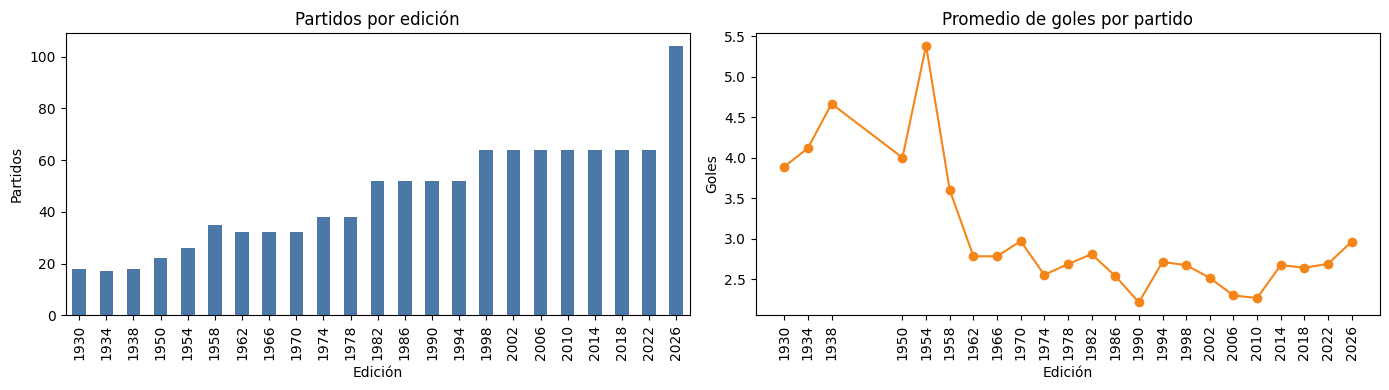

In [ ]:
partidos_por_edicion = pd.Series({a: len(l) for a, l in cup.items()})
goles_por_partido = pd.Series({a: np.mean([p["goles_a"] + p["goles_b"] for p in l]) for a, l in cup.items()})
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
partidos_por_edicion.plot.bar(ax=ejes[0], color="#4C78A8")
ejes[0].set(title="Partidos por edición", xlabel="Edición", ylabel="Partidos")
goles_por_partido.plot(ax=ejes[1], marker="o", color="#F58518")
ejes[1].set(title="Promedio de goles por partido", xlabel="Edición", ylabel="Goles")
ejes[1].set_xticks(goles_por_partido.index, goles_por_partido.index, rotation=90)
plt.tight_layout()
plt.show()

**Partidos y goles por edición.** Las ediciones pasan de 18 partidos en 1930 a 64 entre 1998 y 2022, y 2026 llega a 104 por
la ampliación del torneo (72 partidos de grupos y 32 de eliminatorias). El promedio de goles por partido es más alto en los
primeros torneos (5,4 en 1954) y desde 1962 se mueve entre 2,2 y 3,0.

In [ ]:
filas = []
for anio, partidos in cup.items():
    for p in partidos:
        if "Colombia" in (p["equipo_a"], p["equipo_b"]):
            propio = p["equipo_a"] == "Colombia"
            gf, gc = (p["goles_a"], p["goles_b"]) if propio else (p["goles_b"], p["goles_a"])
            filas.append({"edición": anio, "fase": p["fase"], "rival": p["equipo_b"] if propio else p["equipo_a"],
                          "GF": gf, "GC": gc, "resultado": "G" if gf > gc else "E" if gf == gc else "P",
                          "penales": p["penales"]})
colombia = pd.DataFrame(filas)
resumen = colombia.groupby("edición").agg(PJ=("rival", "size"), G=("resultado", lambda s: (s == "G").sum()),
                                          E=("resultado", lambda s: (s == "E").sum()),
                                          P=("resultado", lambda s: (s == "P").sum()), GF=("GF", "sum"), GC=("GC", "sum"))
print(f"Partidos de Colombia: {len(colombia)} (2026 incluido)")
resumen

Partidos de Colombia: 27 (2026 incluido)


,PJ,G,E,P,GF,GC
edición,,,,,,
1962,3,0,1,2,5,11
1990,4,1,1,2,4,4
1994,3,1,0,2,4,5
1998,3,1,0,2,1,3
2014,5,4,0,1,12,4
2018,4,2,1,1,6,3
2026,5,3,2,0,5,1


**Colombia.** En la tabla, PJ son los partidos jugados; G, E y P, los ganados, empatados y perdidos; y GF y GC, los goles a favor y en contra. Colombia suma 27 partidos en siete ediciones. Su mejor campaña fue la de 2014 (4 victorias en 5 partidos, 12 goles a
favor y 4 en contra) y la más difícil la de 1962 (ninguna victoria, 5 goles a favor y 11 en contra). En 2026 no perdió
(3 victorias y 2 empates).

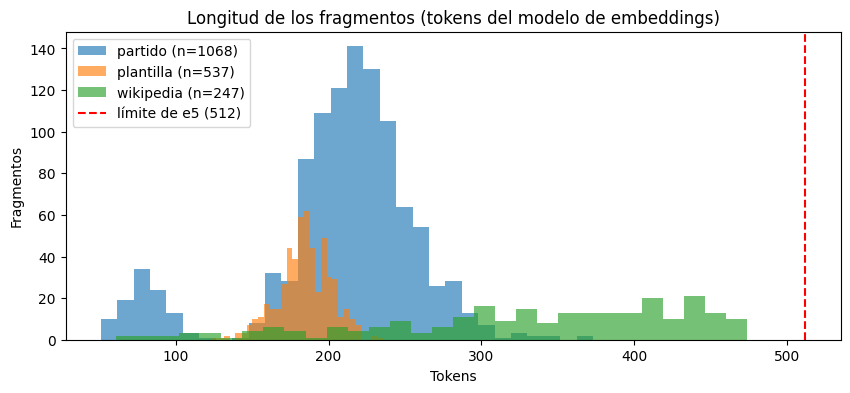

,count,mean,std,min,25%,50%,75%,max
tipo,,,,,,,,
partido,1068.0,208.0,52.0,51.0,191.0,215.0,237.0,373.0
plantilla,537.0,184.0,17.0,124.0,175.0,185.0,196.0,236.0
wikipedia,247.0,334.0,99.0,61.0,282.0,352.0,412.0,474.0


In [ ]:
longitudes = pd.DataFrame({"tipo": [f["metadata"]["tipo"] for f in fragmentos],
                           "tokens": [len(tokenizador(f["texto"])["input_ids"]) for f in fragmentos]})
fig, ax = plt.subplots(figsize=(10, 4))
for tipo, grupo in longitudes.groupby("tipo"):
    ax.hist(grupo["tokens"], bins=30, alpha=0.65, label=f"{tipo} (n={len(grupo)})")
ax.axvline(512, color="red", ls="--", label="límite de e5 (512)")
ax.set(title="Longitud de los fragmentos (tokens del modelo de embeddings)", xlabel="Tokens", ylabel="Fragmentos")
ax.legend()
plt.show()
longitudes.groupby("tipo")["tokens"].describe().round(0)

**Longitud de los fragmentos.** Los 1852 fragmentos (1068 de partido, 537 de plantilla y 247 de Wikipedia) tienen en
promedio 208, 184 y 334 tokens, y el más largo mide 474, por debajo del límite de 512 de e5. Los fragmentos de partido de
unos 80 tokens son los de 2026, que no tiene alineaciones. Diez fragmentos de Wikipedia de la longitud máxima ocupan unos
4700 tokens, dentro de los 8192 de `num_ctx`.

## 5. Índice y pipeline base

Los embeddings son `multilingual-e5-large`, que exige el prefijo `passage:` en los textos indexados y `query:` en las
consultas. Los vectores se normalizan, de modo que el producto interno de FAISS equivale a la similitud coseno. Cada
configuración (modelo y prefijos) se guarda en su propio directorio junto con una huella del corpus: si el corpus, el
modelo o los prefijos cambian, el índice guardado se descarta y se reconstruye.

In [ ]:
class EmbeddingsE5(Embeddings):
    """e5 exige 'passage: ' en los textos indexados y 'query: ' en las consultas; `prefijos=False` los omite."""

    def __init__(self, modelo=MODELO_EMBEDDINGS, prefijos=True, lote=32, dispositivo=None):
        self.nombre = modelo
        self.modelo = SentenceTransformer(modelo, device=dispositivo)
        self.prefijos, self.lote = prefijos, lote

    def con_prefijos(self, prefijos):
        """Misma instancia del modelo (sin recargarlo) con otra configuración de prefijos."""
        copia = copy.copy(self)
        copia.prefijos = prefijos
        return copia

    def _codifica(self, textos, prefijo, barra=False):
        pre = prefijo if self.prefijos else ""
        return self.modelo.encode([pre + t for t in textos], batch_size=self.lote,
                                  normalize_embeddings=True, show_progress_bar=barra)

    def embed_documents(self, textos):
        return self._codifica(textos, "passage: ", barra=len(textos) > 50).tolist()

    def embed_query(self, texto):
        return self._codifica([texto], "query: ")[0].tolist()


def a_documentos(fragmentos):
    """Convierte los fragmentos en `Document`; `id` identifica de forma estable cada fragmento (para las métricas)."""
    return [Document(page_content=f["texto"], metadata={**f["metadata"], "id": f"{i:04d}"})
            for i, f in enumerate(fragmentos)]


def nombre_indice(modelo, prefijos, humo=False):
    """Cada configuración tiene su propio directorio: 'multilingual-e5-large_con_prefijos', '..._sin_prefijos_humo'."""
    return f"{modelo.split('/')[-1]}_{'con' if prefijos else 'sin'}_prefijos" + ("_humo" if humo else "")


def huella(documentos, embeddings):
    """Resume corpus + modelo + prefijos: si cambia alguno, el índice guardado ya no corresponde."""
    h = hashlib.sha1(f"{embeddings.nombre}|{embeddings.prefijos}".encode())
    for d in documentos:
        h.update(d.page_content.encode())
    return h.hexdigest()


def construye_indice(documentos, embeddings, ruta, reconstruir=False):
    """Carga el índice FAISS de `ruta` o lo construye (y guarda) si no existe, si `reconstruir=True` o si la huella
    del corpus/modelo cambió. Los vectores van normalizados: el producto interno equivale a la similitud coseno."""
    ruta, h = Path(ruta), huella(documentos, embeddings)
    meta = ruta / "meta.json"
    if ruta.exists() and not reconstruir:
        if meta.exists() and json.loads(meta.read_text())["huella"] == h:
            return FAISS.load_local(str(ruta), embeddings, allow_dangerous_deserialization=True,
                                    distance_strategy=DistanceStrategy.MAX_INNER_PRODUCT)
        print(f"Aviso: el índice '{ruta.name}' no corresponde al corpus actual; se reconstruye.")
    t0 = time.time()
    vectores = np.asarray(embeddings.embed_documents([d.page_content for d in documentos]), dtype="float32")
    indice = FAISS.from_embeddings(
        list(zip([d.page_content for d in documentos], vectores)), embeddings,
        metadatas=[d.metadata for d in documentos], distance_strategy=DistanceStrategy.MAX_INNER_PRODUCT)
    indice.save_local(str(ruta))
    meta.write_text(json.dumps({"huella": h, "modelo": embeddings.nombre, "prefijos": embeddings.prefijos,
                                "fragmentos": len(documentos)}))
    print(f"Índice '{ruta.name}' construido en {time.time() - t0:.0f} s: "
          f"{indice.index.ntotal} vectores de {indice.index.d} dimensiones")
    return indice

In [ ]:
documentos = a_documentos(fragmentos)
emb_base = EmbeddingsE5(MODELO_EMBEDDINGS, dispositivo=dispositivo, lote=64 if dispositivo == "cuda" else 16)
with crono.etapa(f"índice {MODELO_EMBEDDINGS.split('/')[-1]} · con prefijos"):
    indice_base = construye_indice(documentos, emb_base.con_prefijos(True),
                                   DIR_INDICES / nombre_indice(MODELO_EMBEDDINGS, True, SMOKE_TEST), reconstruir=REBUILD_INDEX)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Índice 'multilingual-e5-large_con_prefijos' construido en 85 s: 1852 vectores de 1024 dimensiones


El pipeline base recupera los k fragmentos más cercanos y los entrega al modelo con instrucciones explícitas: responder en
español, solo con el contexto, copiar marcadores y nombres sin calcular, citar la fuente y admitir cuando el dato no está.
Las fuentes se muestran a partir de los metadatos de cada fragmento, no del texto.

In [ ]:
def sin_tildes(texto):
    return "".join(c for c in unicodedata.normalize("NFKD", texto) if not unicodedata.combining(c)).lower()


def tokeniza(texto):
    """Minúsculas y sin tildes, para que 'Zúñiga' (alineaciones) y 'ZUNIGA' (plantillas) coincidan."""
    return re.findall(r"\w+", sin_tildes(texto))


class RecuperadorDenso:
    def __init__(self, indice):
        self.indice = indice

    def __call__(self, consulta, k):
        return [d for d, _ in self.indice.similarity_search_with_score(consulta, k=k)]


class RecuperadorBM25:
    def __init__(self, documentos):
        self.documentos = documentos
        self.bm25 = BM25Okapi([tokeniza(d.page_content) for d in documentos])

    def __call__(self, consulta, k):
        puntajes = self.bm25.get_scores(tokeniza(consulta))
        orden = np.argsort(-puntajes, kind="stable")[:k]
        return [self.documentos[i] for i in orden]


class RecuperadorHibrido:
    """Fusiona los rankings denso y BM25 con Reciprocal Rank Fusion: puntaje = suma de 1 / (c + posición)."""

    def __init__(self, denso, bm25, c=60, candidatos=50):
        self.denso, self.bm25, self.c, self.candidatos = denso, bm25, c, candidatos

    def __call__(self, consulta, k):
        puntaje, docs = defaultdict(float), {}
        for ranking in (self.denso(consulta, self.candidatos), self.bm25(consulta, self.candidatos)):
            for pos, d in enumerate(ranking, 1):
                puntaje[d.metadata["id"]] += 1.0 / (self.c + pos)
                docs[d.metadata["id"]] = d
        mejores = sorted(puntaje, key=lambda i: -puntaje[i])[:k]
        return [docs[i] for i in mejores]


PROMPT_SISTEMA = (
    "Eres un asistente sobre los Mundiales de fútbol (1930-2026), con énfasis en la Selección Colombia. "
    "Responde siempre en español y únicamente con la información del contexto. "
    "Si la respuesta no está en el contexto, di que no cuentas con esa información. "
    "Copia marcadores, fechas y nombres tal como aparecen; no calcules ni infieras cifras. "
    "Cita la fuente con su número entre corchetes, por ejemplo [1]. Responde de forma breve."
)


PROMPT = ChatPromptTemplate.from_messages([
    ("system", PROMPT_SISTEMA + "\n\nContexto:\n{contexto}"),
    ("human", "{pregunta}"),
])


def etiqueta_fuente(doc):
    """Descripción corta de un fragmento a partir de sus metadatos (sin depender del texto)."""
    m = doc.metadata
    if m["tipo"] == "wikipedia":
        return f"Wikipedia · {m['seccion']} ({m['fuente']}, descargado el {m['fecha_descarga']})"
    equipos = " vs ".join(m["equipos"])
    return f"{m['tipo'].capitalize()} · Mundial {m['edicion']} · {m['fase'] or 'plantilla'} · {equipos} ({m['fuente']})"


def formatea_contexto(docs):
    return "\n\n".join(f"[{i}] {d.page_content}" for i, d in enumerate(docs, 1))


def responde(pregunta, recuperador, llm):
    """Recupera, genera y devuelve la respuesta junto con los fragmentos usados."""
    docs = recuperador(pregunta)
    cadena = PROMPT | llm | StrOutputParser()
    respuesta = cadena.invoke({"contexto": formatea_contexto(docs), "pregunta": pregunta})
    return respuesta, docs

In [ ]:
recuperador_base = RecuperadorDenso(indice_base)
pregunta = "¿Cómo terminó Colombia contra la Unión Soviética en 1962?"
respuesta, docs = responde(pregunta, lambda q: recuperador_base(q, 5), llm)
print(respuesta)
print()
for i, d in enumerate(docs, 1):
    print(f"[{i}] {etiqueta_fuente(d)}")

Colombia empató 4-4 con la Unión Soviética en el partido del Grupo 1 del Mundial de Fútbol de 1962, que se jugó el 3 de junio de 1962 en el Estadio Carlos Dittborn de Arica, Chile.

[1] Partido · Mundial 1962 · Group 1 · Soviet Union vs Colombia (wikipedia/1962.txt:170; 1962--chile/cup.txt:21)
[2] Wikipedia · Chile 1962 (https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Colombia, descargado el 2026-10-05)
[3] Partido · Mundial 1962 · Group 1 · Yugoslavia vs Colombia (wikipedia/1962.txt:276; 1962--chile/cup.txt:24)
[4] Partido · Mundial 1962 · Group 1 · Uruguay vs Colombia (wikipedia/1962.txt:9; 1962--chile/cup.txt:17)
[5] Partido · Mundial 1962 · Group 1 · Soviet Union vs Uruguay (wikipedia/1962.txt:224; 1962--chile/cup.txt:23)


## 6. Chat conversacional

La conversación necesita memoria: en un seguimiento como «¿y quiénes marcaron los goles?» la pregunta sola no dice de qué
partido se habla. Cuando hay historial, el modelo reformula la pregunta para que se entienda sin él y con esa versión se
recupera; la respuesta se genera con la pregunta original. Como un modelo de 3B no siempre reformula bien, el código guarda
la salida cruda de la reformulación y, si no sirve (vacía, desmedida, una negativa o idéntica a la pregunta) y la pregunta
parece un seguimiento (corta y sin año), la consulta se arma uniendo la pregunta anterior con la nueva, sin pasar por el
modelo. El prompt de reformulación incluye un ejemplo. La guía resuelve esto con `create_history_aware_retriever`; aquí
se implementa de forma explícita para controlar el k y conservar la pregunta reformulada.

La memoria está implementada (reformulación con historial y respaldo por unión de preguntas), pero no se presenta como
resuelta: falla en casos como el seguimiento del 4-4 de Colombia contra la Unión Soviética, que se muestra tal cual en la
sección 9 y se resume en la sección 10.

In [ ]:
MAX_CONSULTA = 300  # caracteres; una pregunta autosuficiente no debería ser más larga


ABSTENCION = re.compile(r"no cuento|no tengo|no dispongo|no se encuentra|no aparece|no hay informacion|"
                        r"no puedo|no esta en el contexto|no menciona|no se menciona")


def es_abstencion(respuesta):
    return bool(ABSTENCION.search(sin_tildes(respuesta)))


ANIO = re.compile(r"\b(?:1[89]|20)\d\d\b")


def parece_seguimiento(pregunta):
    """Pregunta corta y sin año: sola no dice de qué partido se habla. Sirve de respaldo si la reformulación falla."""
    return not ANIO.search(pregunta) and len(pregunta.split()) <= 10


PROMPT_REFORMULA = ChatPromptTemplate.from_messages([
    ("system", "Con el historial de la conversación, reescribe la última pregunta para que se entienda sola, "
               "en español, conservando equipos, años y nombres. No la respondas: devuelve únicamente la pregunta.\n"
               "Ejemplo. Historial: «¿Cuál fue el marcador de Francia contra Croacia en 2018?». Última pregunta: "
               "«¿Y quién entrenaba a Francia?». Respuesta: «¿Quién dirigió a Francia en el Mundial de 2018?»"),
    ("placeholder", "{historial}"),
    ("human", "{pregunta}"),
])


@dataclass
class Respuesta:
    texto: str
    docs: list
    consulta: str  # pregunta ya reformulada con el historial; es la que se usó para recuperar
    reformulacion: str = None  # salida cruda del modelo al reformular (None si no había historial)
    origen: str = "original"  # "reformulada", "unida" (pregunta anterior + nueva, sin el modelo) u "original"


class ChatMundial:
    """Chatbot conversacional con RAG sobre Mundiales: recupera con la pregunta autosuficiente y recuerda los turnos."""

    def __init__(self, recuperador, llm, k=5, max_turnos=6):
        self.recuperador, self.llm, self.k, self.max_turnos = recuperador, llm, k, max_turnos
        self.historial = []
        self._reformula = PROMPT_REFORMULA | llm | StrOutputParser()
        self._responde = PROMPT | llm | StrOutputParser()

    def reiniciar(self):
        self.historial.clear()

    def _mensajes(self):
        return [m for p, r in self.historial[-self.max_turnos:] for m in (HumanMessage(p), AIMessage(r))]

    def preguntar(self, pregunta):
        consulta, cruda, origen = pregunta, None, "original"
        if self.historial:
            cruda = self._reformula.invoke({"historial": self._mensajes(), "pregunta": pregunta}).strip()
            util = cruda and len(cruda) <= MAX_CONSULTA and not es_abstencion(cruda)  # no vacía, ni desmedida, ni negativa
            if util and sin_tildes(cruda) != sin_tildes(pregunta):
                consulta, origen = cruda, "reformulada"
            elif parece_seguimiento(pregunta):
                # El modelo no reformuló: se une la pregunta anterior con la nueva, sin pasar por el modelo
                consulta, origen = f"{self.historial[-1][0]} {pregunta}", "unida"
        docs = self.recuperador(consulta, self.k)
        texto = self._responde.invoke({"contexto": formatea_contexto(docs), "pregunta": pregunta})
        self.historial.append((pregunta, texto))
        return Respuesta(texto=texto, docs=docs, consulta=consulta, reformulacion=cruda, origen=origen)


def respuesta_con_fuentes(r):
    """Respuesta seguida de las fuentes; cada fragmento recuperado se despliega en un acordeón."""
    fuentes = "\n".join(
        f"<details><summary>[{i}] {etiqueta_fuente(d)}</summary>\n\n<pre>{d.page_content}</pre>\n\n</details>"
        for i, d in enumerate(r.docs, 1))
    return f"{r.texto}\n\n**Fuentes recuperadas**\n\n{fuentes}"


def crea_interfaz(chat):
    with gr.Blocks(title="Chatbot conversacional con RAG sobre Mundiales de fútbol") as demo:
        gr.Markdown("## Chatbot conversacional con RAG sobre Mundiales de fútbol (1930–2026)\n"
                    "Responde en español con base en partidos, plantillas y artículos de Wikipedia. "
                    "Si el dato no está en esas fuentes, lo indica.")
        ventana = gr.Chatbot(height=460)
        caja = gr.Textbox(label="Pregunta", placeholder="Escribe tu pregunta y presiona Enter")
        limpiar = gr.Button("Nueva conversación")

        def enviar(pregunta, mensajes):
            r = chat.preguntar(pregunta)
            mensajes = (mensajes or []) + [{"role": "user", "content": pregunta},
                                           {"role": "assistant", "content": respuesta_con_fuentes(r)}]
            return "", mensajes

        def reiniciar():
            chat.reiniciar()
            return "", []

        caja.submit(enviar, [caja, ventana], [caja, ventana])
        limpiar.click(reiniciar, None, [caja, ventana], queue=False)
    return demo

In [ ]:
asegura_ollama()
chat = ChatMundial(recuperador_base, llm, k=5)
for pregunta in ["¿Cómo terminó Colombia contra la Unión Soviética en 1962?", "¿Y quiénes marcaron los goles?"]:
    r = chat.preguntar(pregunta)
    print(f"Pregunta: {pregunta}\nReformulación cruda: {r.reformulacion!r}\nConsulta usada ({r.origen}): {r.consulta}\nRespuesta: {r.texto}\n")
chat.reiniciar()

Pregunta: ¿Cómo terminó Colombia contra la Unión Soviética en 1962?
Reformulación cruda: None
Consulta usada (original): ¿Cómo terminó Colombia contra la Unión Soviética en 1962?
Respuesta: Colombia empató 4-4 con la Unión Soviética en el partido del Grupo 1 del Mundial de Fútbol de 1962, que se jugó el 3 de junio de 1962 en el Estadio Carlos Dittborn de Arica, Chile.

Pregunta: ¿Y quiénes marcaron los goles?
Reformulación cruda: 'No tengo información sobre los goles específicos de ese partido.'
Consulta usada (unida): ¿Cómo terminó Colombia contra la Unión Soviética en 1962? ¿Y quiénes marcaron los goles?
Respuesta: En el partido del Mundial 1962 entre Colombia y Uruguay, los goles fueron anotados por:

* Francisco Zuluaga (Colombia) en el minuto 19' (p)
* Luis Cubilla (Uruguay) en el minuto 56'
* José Sasía (Uruguay) en el minuto 75'



## 7. Evaluación y experimentos

### 7.1 Preguntas de evaluación

Las preguntas se generan automáticamente desde los registros, de modo que la respuesta correcta ya está en el dato:
marcador de un partido, jugador que entró por otro, entrenador de una selección, titulares de un partido y convocados de
una plantilla. Solo se usan cruces que se jugaron una vez en la edición, para que la pregunta no sea ambigua, y los
partidos sin prórroga para que el marcador sea único. Una parte de cada tipo se reserva para Colombia. Los tipos
«marcador», «cambio» y «entrenador» tienen respuesta exacta comprobable; «convocados» solo se evalúa en recuperación, y
«titulares» además en generación con una métrica de coincidencia de nombres (*cobertura de titulares*). Se agregan 10 preguntas fuera de dominio para medir si el modelo reconoce que no tiene el dato y, en sentido
contrario, cuántas preguntas del dominio reciben una abstención por error (*abstención indebida*).

**Limitación.** Estas preguntas siguen cinco plantillas y repiten las palabras del fragmento («marcador de X contra Y en el
Mundial de Z»), por lo que son más fáciles para el buscador que las de una persona real. Por eso se añade un segundo
conjunto, `PREGUNTAS_EJEMPLO`, con preguntas de ejemplo y otras redactadas sin copiar la plantilla. El
dato esperado de cada una se toma del registro, no se escribe en la pregunta. Los conjuntos se reportan por separado y no se
promedian. Las preguntas de ejemplo que no tienen un único fragmento correcto (el contexto de Wikipedia y el seguimiento
conversacional) no entran en estas métricas y se prueban en las demos.

Un tercer conjunto, `PREGUNTAS_GRUPO_QUEBEC`, reúne preguntas redactadas por el grupo Quebec y se resuelve igual: el fragmento y el dato
esperado salen del registro, y se descartaría cualquiera que no tenga un único partido o plantilla. Se reporta aparte de
los otros dos. Para el marcador, `acierta` acepta los dos órdenes (7-1 o 1-7), de modo que no verifica quién ganó.

In [ ]:
KS = (1, 3, 5, 10)


PREGUNTAS_POR_TIPO = {"marcador": 14, "cambio": 8, "entrenador": 6, "alineacion": 6, "plantilla": 6}


FUERA_DE_DOMINIO = ["¿Quién ganó el último Roland Garros?", "¿Cuál es la capital de Australia?",
                    "¿Cómo se prepara un ajiaco santafereño?", "¿Qué temperatura hace hoy en Cali?",
                    "¿Cómo se resuelve una ecuación de segundo grado?", "¿Quién ganó la última Liga de Campeones de la UEFA?",
                    "¿Cuántos goles marcó Messi en la temporada 2019-2020 con el Barcelona?",
                    "¿Quién ganó la Copa América de 2024?", "¿Quién es el técnico actual del Real Madrid?",
                    "¿Cuál es la fórmula química del agua oxigenada?"]


PREGUNTAS_EJEMPLO = [
    {"pregunta": "¿Cuál fue el marcador de Brasil contra Croacia en 2014?", "tipo": "marcador", "edicion": 2014, "equipos": ("Brazil", "Croatia")},
    {"pregunta": "¿Cómo terminó Colombia contra la Unión Soviética en 1962?", "tipo": "marcador", "edicion": 1962, "equipos": ("Colombia", "Soviet Union")},
    {"pregunta": "¿Cuánto quedó Japón contra Colombia en 2014?", "tipo": "marcador", "edicion": 2014, "equipos": ("Japan", "Colombia")},
    {"pregunta": "¿Quién entró por Giovanni en el Brasil–Escocia de 1998?", "tipo": "cambio", "edicion": 1998, "equipos": ("Brazil", "Scotland"), "sale": "Giovanni"},
    {"pregunta": "¿Quiénes fueron titulares de Colombia contra Uruguay en 1962?", "tipo": "alineacion", "edicion": 1962, "equipos": ("Colombia", "Uruguay")},
    {"pregunta": "¿Qué jugadores convocó Colombia en 2014?", "tipo": "plantilla", "edicion": 2014, "equipos": ("Colombia",)},
    {"pregunta": "¿Quién era el técnico de Colombia en 2014?", "tipo": "entrenador", "edicion": 2014, "equipos": ("Colombia",)},
    {"pregunta": "¿Quién fue el entrenador de Brasil en 1998?", "tipo": "entrenador", "edicion": 1998, "equipos": ("Brazil",)},
]


def es(equipo):
    """Nombre del equipo en español (el primer alias), como lo escribiría quien pregunta."""
    return ALIAS_ES[equipo].split(",")[0]


CAMBIO = re.compile(r"([^,()]+?) \((\d+(?:\+\d+)?)' ([^,()]+?)\)")


def nombres_titulares(texto):
    """Titulares de una alineación del registro («Nombre, Nombre (46' Suplente), ...»), sin los suplentes."""
    return [re.sub(r"\s*\(.*?\)", "", n).strip() for n in texto.split(", ") if n.strip()]


def cobertura_nombres(respuesta, nombres):
    """Fracción de `nombres` que aparecen en la respuesta (nombre completo, o apellido si no se repite en la lista).
    Mide omisiones, no nombres inventados o de otra alineación; sirve para detectar listas incompletas."""
    r, apellidos = sin_tildes(respuesta), Counter(sin_tildes(n).split()[-1] for n in nombres)
    def aparece(n):
        completo = sin_tildes(n)
        return completo in r or (apellidos[completo.split()[-1]] == 1 and re.search(rf"\b{re.escape(completo.split()[-1])}\b", r))
    return sum(bool(aparece(n)) for n in nombres) / len(nombres) if nombres else float("nan")


def candidatos(fragmentos):
    """Para cada tipo de pregunta, las posibles (pregunta, gold_id, esperado, equipos) con respuesta única en los datos."""
    por_edicion = Counter((f["registro"]["edicion"], frozenset((f["registro"]["equipo_a"], f["registro"]["equipo_b"])))
                          for f in fragmentos if f["metadata"]["tipo"] == "partido")
    c = {t: [] for t in PREGUNTAS_POR_TIPO}
    for i, f in enumerate(fragmentos):
        gid, m, r = f"{i:04d}", f["metadata"], f.get("registro")
        if m["tipo"] == "partido":
            a, b, anio = r["equipo_a"], r["equipo_b"], r["edicion"]
            if por_edicion[(anio, frozenset((a, b)))] != 1:
                continue  # el mismo cruce se jugó dos veces en la edición: la pregunta sería ambigua
            if not r["prorroga"]:
                c["marcador"].append({"pregunta": f"¿Cuál fue el marcador de {es(a)} contra {es(b)} en el Mundial de {anio}?",
                                      "gold_id": gid, "esperado": (r["goles_a"], r["goles_b"]), "equipos": m["equipos"]})
            for eq, texto in (r.get("alineaciones") or {}).items():
                c["alineacion"].append({"pregunta": f"¿Quiénes fueron los titulares de {es(eq)} contra "
                                                    f"{es(b if eq == a else a)} en el Mundial de {anio}?",
                                        "gold_id": gid, "esperado": None, "equipos": m["equipos"],
                                        "titulares": nombres_titulares(texto)})
                cambios = CAMBIO.findall(texto)
                salidas = Counter(s.strip() for s, _, _ in cambios)
                for sale, _, entra in cambios:
                    if salidas[sale.strip()] == 1:
                        c["cambio"].append({"pregunta": f"¿Quién entró por {sale.strip()} en el partido {es(a)}–{es(b)} del Mundial de {anio}?",
                                            "gold_id": gid, "esperado": entra.strip(), "equipos": m["equipos"]})
        elif m["tipo"] == "plantilla":
            eq, anio = m["equipos"][0], m["edicion"]
            c["plantilla"].append({"pregunta": f"¿Qué jugadores convocó {es(eq)} en el Mundial de {anio}?",
                                   "gold_id": gid, "esperado": None, "equipos": m["equipos"]})
            if len(r["entrenadores"]) == 1:
                nombre = r["entrenadores"][0]["nombre"].split("(")[0].split()
                c["entrenador"].append({"pregunta": f"¿Quién dirigió a {es(eq)} en el Mundial de {anio}?",
                                        "gold_id": gid, "esperado": nombre[-1].title(), "equipos": m["equipos"]})
    return c


def genera_preguntas(fragmentos, por_tipo=None, semilla=42, enfasis="Colombia", fraccion_enfasis=0.3):
    """Muestra reproducible de preguntas; una parte de cada tipo se reserva, si hay, para el equipo de énfasis."""
    por_tipo, rng, preguntas = por_tipo or PREGUNTAS_POR_TIPO, random.Random(semilla), []
    for tipo, cand in candidatos(fragmentos).items():
        n = min(por_tipo.get(tipo, 0), len(cand))
        con = [q for q in cand if enfasis in q["equipos"]]
        sin = [q for q in cand if enfasis not in q["equipos"]]
        rng.shuffle(con), rng.shuffle(sin)
        n_con = round(n * fraccion_enfasis)
        elegidas = con[:n_con]
        elegidas += sin[:n - len(elegidas)]
        elegidas += con[n_con:][:n - len(elegidas)]  # si faltan preguntas sin el equipo de énfasis, se completa con las que sobran
        preguntas += [{**q, "tipo": tipo} for q in elegidas[:n]]
    return preguntas


PREGUNTAS_GRUPO_QUEBEC = [
    {"pregunta": "¿Cómo quedó el partido de Colombia y El Congo en el mundial de 2026?", "tipo": "marcador", "edicion": 2026, "equipos": ("Colombia", "DR Congo")},
    {"pregunta": "¿Cual fue el entrenador de Italia en el mundial de 2010?", "tipo": "entrenador", "edicion": 2010, "equipos": ("Italy",)},
    {"pregunta": "¿Quienes fueron los convocados a la selección de España en el mundial de 1998?", "tipo": "plantilla", "edicion": 1998, "equipos": ("Spain",)},
    {"pregunta": "¿Quién entró por Fred en el partido de Brasil contra Alemania en 2014?", "tipo": "cambio", "edicion": 2014, "equipos": ("Brazil", "Germany"), "sale": "Fred"},
    {"pregunta": "¿Cómo quedó la final del Mundial de 1958 entre Brasil y Suecia?", "tipo": "marcador", "edicion": 1958, "equipos": ("Brazil", "Sweden")},
]


def resuelve_preguntas(fragmentos, specs=PREGUNTAS_EJEMPLO):
    """Resuelve un conjunto de preguntas redactadas (`PREGUNTAS_EJEMPLO`, `PREGUNTAS_GRUPO_QUEBEC` u otro con el mismo formato) contra los fragmentos: gold_id y dato
    esperado salen del registro. Si un partido o plantilla no está en `fragmentos` (por ejemplo en el subconjunto de
    prueba rápida), se omite."""
    resueltas = []
    for spec in specs:
        equipos = set(spec["equipos"])
        for i, f in enumerate(fragmentos):
            m, r = f["metadata"], f.get("registro")
            if spec["tipo"] in ("marcador", "cambio", "alineacion"):
                if m["tipo"] != "partido" or r["edicion"] != spec["edicion"] or {r["equipo_a"], r["equipo_b"]} != equipos:
                    continue
                if spec["tipo"] == "marcador":
                    esperado = (r["goles_a"], r["goles_b"])
                elif spec["tipo"] == "cambio":
                    esperado = next((entra.strip() for texto in (r.get("alineaciones") or {}).values()
                                     for sale, _, entra in CAMBIO.findall(texto) if sale.strip() == spec["sale"]), None)
                else:
                    esperado = None
                    titulares = nombres_titulares(r["alineaciones"][spec["equipos"][0]])
            else:
                if m["tipo"] != "plantilla" or m["edicion"] != spec["edicion"] or m["equipos"][0] not in equipos:
                    continue
                esperado = r["entrenadores"][0]["nombre"].split("(")[0].split()[-1].title() if spec["tipo"] == "entrenador" else None
            resueltas.append({"pregunta": spec["pregunta"], "gold_id": f"{i:04d}", "esperado": esperado,
                              "equipos": m["equipos"], "tipo": spec["tipo"],
                              **({"titulares": titulares} if spec["tipo"] == "alineacion" else {})})
            break
    return resueltas


def rango_gold(docs, gold_id):
    return next((i for i, d in enumerate(docs, 1) if d.metadata["id"] == gold_id), None)


def mide_recuperador(recuperador, preguntas, kmax=max(KS), desc=""):
    """Una fila por pregunta: tipo, posición del fragmento correcto (None si no aparece) y latencia en ms.
    Se recupera una sola vez con el k máximo; los demás k son recortes del mismo ranking."""
    recuperador(preguntas[0]["pregunta"], kmax)  # calentamiento: no se cuenta en la latencia
    filas, barra = [], tqdm(total=len(preguntas), desc=desc, leave=False)
    for q in preguntas:
        barra.set_postfix_str(q["pregunta"][:60])
        t0 = perf_counter()
        docs = recuperador(q["pregunta"], kmax)
        filas.append({"tipo": q["tipo"], "rango": rango_gold(docs, q["gold_id"]),
                      "ms": (perf_counter() - t0) * 1000})
        barra.update()
    barra.close()
    return pd.DataFrame(filas)


def resume_recuperador(detalle, ks=KS):
    """Recall@k, MRR y latencia a partir del detalle por pregunta."""
    rango = detalle["rango"]
    res = {f"recall@{k}": float((rango <= k).mean()) for k in ks}  # los None (NaN) no cuentan como acierto
    res["mrr"] = float((1 / rango).fillna(0).mean())
    res["latencia_ms"] = float(detalle["ms"].mean())
    res["latencia_p95_ms"] = float(np.percentile(detalle["ms"], 95))
    res["n_preguntas"] = len(detalle)
    return res


def acierta(respuesta, esperado):
    """Dato directo: marcador (g1, g2) en cualquiera de los dos órdenes, o nombre. Sin tildes y sin distinguir mayúsculas.
    Aceptar ambos órdenes no verifica quién ganó: «7-1» y «1-7» cuentan igual."""
    r = sin_tildes(respuesta)
    if isinstance(esperado, tuple):
        return any(re.search(rf"(?<!\d){a}\s*(?:-|–|:|a|x)\s*{b}(?!\d)", r) for a, b in (esperado, esperado[::-1]))
    return sin_tildes(esperado.split()[-1]) in r


def responder_sin_rag(llm):
    """Misma pregunta, sin contexto recuperado: línea base para medir cuánto aporta la memoria no paramétrica."""
    cadena = ChatPromptTemplate.from_messages([
        ("system", "Eres un asistente sobre fútbol. Responde en español y de forma breve."),
        ("human", "{pregunta}")]) | llm | StrOutputParser()
    return lambda pregunta: (cadena.invoke({"pregunta": pregunta}), [])


ERRORES_LLM = (httpx.TransportError, ollama.ResponseError)


def responde_con_reintento(responder, pregunta, reintentar=None):
    """`responder(pregunta) -> (texto, docs)`. Si el modelo no contesta (`ERRORES_LLM`), se llama a `reintentar()`
    (por ejemplo, comprobar y relanzar Ollama) y se intenta una vez más. Devuelve (texto, docs, error): si el segundo
    intento también falla, texto vacío, sin documentos y el error como texto, en lugar de bloquear la celda."""
    for intento in (1, 2):
        try:
            texto, docs = responder(pregunta)
            return texto, docs, None
        except ERRORES_LLM as e:
            error = f"{type(e).__name__}: {e}"
            if intento == 1 and reintentar:
                reintentar()
    return "", [], error


def evalua_generacion(responder, preguntas, fuera_de_dominio=(), reintentar=None, config=""):
    """`responder(pregunta) -> (texto, docs)`. Exactitud sobre preguntas de dato directo, abstención fuera de dominio,
    abstención indebida (el modelo dice que no sabe en una pregunta de dominio, cuyo dato sí existe) y cobertura de
    titulares. Una pregunta cuyo modelo falla dos veces se registra con su error (`n_errores`): cuenta como incorrecta
    en la exactitud y no entra en los demás promedios."""
    directas, filas, tiempos, n_errores = [q for q in preguntas if q["esperado"] is not None], [], [], 0
    con_titulares = [q for q in preguntas if q.get("titulares")]
    barra = tqdm(total=len(directas) + len(fuera_de_dominio) + len(con_titulares), desc=config, leave=False)

    def llama(pregunta):
        barra.set_postfix_str(pregunta[:60])
        resultado = responde_con_reintento(responder, pregunta, reintentar)
        barra.update()
        return resultado

    for q in directas:
        t0 = perf_counter()
        texto, docs, error = llama(q["pregunta"])
        if error is None:
            tiempos.append(perf_counter() - t0)
        n_errores += error is not None
        filas.append({"tipo": q["tipo"], "pregunta": q["pregunta"], "esperado": q["esperado"], "respuesta": texto,
                      "acierta": error is None and acierta(texto, q["esperado"]),
                      "se_abstiene": None if error else es_abstencion(texto), "error": error,
                      "gold_en_contexto": rango_gold(docs, q["gold_id"]) is not None if docs else None})
    abst = []
    for p in fuera_de_dominio:
        texto, _, error = llama(p)
        n_errores += error is not None
        if error is None:
            abst.append(es_abstencion(texto))
    df = pd.DataFrame(filas)
    filas_titulares = []
    for q in con_titulares:
        texto, docs, error = llama(q["pregunta"])
        n_errores += error is not None
        filas_titulares.append({"pregunta": q["pregunta"], "respuesta": texto, "error": error,
                                "cobertura": float("nan") if error else cobertura_nombres(texto, q["titulares"]),
                                "gold_en_contexto": rango_gold(docs, q["gold_id"]) is not None if docs else None})
    barra.close()
    df_titulares = pd.DataFrame(filas_titulares)
    return {"detalle": df, "detalle_titulares": df_titulares,
            "cobertura_titulares": float(df_titulares["cobertura"].mean()) if len(df_titulares) else float("nan"),
            "exactitud": float(df["acierta"].mean()) if len(df) else float("nan"),
            "abstencion_fuera_de_dominio": float(np.mean(abst)) if abst else float("nan"),
            "abstencion_indebida": float(df["se_abstiene"].dropna().astype(bool).mean()) if len(df) else float("nan"),
            "n_errores": n_errores,
            "latencia_respuesta_s": statistics.mean(tiempos) if tiempos else float("nan")}


def mapa_calor_recall(df, ks=KS):
    """`df`: una fila por configuración, con columnas 'config' y 'recall@k'."""
    datos = df.set_index("config")[[f"recall@{k}" for k in ks]]
    fig, ax = plt.subplots(figsize=(1.6 * len(ks) + 2, 0.6 * len(datos) + 1.5))
    im = ax.imshow(datos.values, vmin=0, vmax=1, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(len(ks)), [f"k={k}" for k in ks])
    ax.set_yticks(range(len(datos)), datos.index)
    for (i, j), v in np.ndenumerate(datos.values):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.6 else "black")
    fig.colorbar(im, ax=ax, label="Recall@k")
    ax.set_title("Recall@k por configuración de recuperación")
    plt.tight_layout()
    return fig


def barras_latencia(df):
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(df) + 1.5))
    ax.barh(df["config"], df["latencia_ms"], color="#4C78A8")
    ax.set_xlabel("Latencia media por consulta (ms)")
    ax.set_title("Latencia de recuperación por configuración")
    ax.invert_yaxis()
    plt.tight_layout()
    return fig

In [ ]:
por_tipo = {t: 2 for t in PREGUNTAS_POR_TIPO} if SMOKE_TEST else PREGUNTAS_POR_TIPO
preguntas = genera_preguntas(fragmentos, por_tipo=por_tipo, semilla=SEMILLA)
fuera_de_dominio = FUERA_DE_DOMINIO[:2] if SMOKE_TEST else FUERA_DE_DOMINIO
print(f"{len(preguntas)} preguntas de evaluación, {sum('Colombia' in q['equipos'] for q in preguntas)} de ellas con Colombia")
print(pd.Series([q["tipo"] for q in preguntas]).value_counts().to_string())
pd.DataFrame(preguntas)[["tipo", "pregunta", "esperado"]].head(8)

40 preguntas de evaluación, 12 de ellas con Colombia
marcador      14
cambio         8
entrenador     6
alineacion     6
plantilla      6


,tipo,pregunta,esperado
0,marcador,¿Cuál fue el marcador de Colombia contra Urugu...,"(2, 0)"
1,marcador,¿Cuál fue el marcador de Alemania Occidental c...,"(1, 1)"
2,marcador,¿Cuál fue el marcador de Polonia contra Colomb...,"(0, 3)"
3,marcador,¿Cuál fue el marcador de Colombia contra Ghana...,"(1, 0)"
4,marcador,¿Cuál fue el marcador de Argentina contra Hung...,"(2, 1)"
5,marcador,¿Cuál fue el marcador de Italia contra Paragua...,"(2, 0)"
6,marcador,¿Cuál fue el marcador de Camerún contra Países...,"(1, 2)"
7,marcador,¿Cuál fue el marcador de Polonia contra Argent...,"(3, 2)"


In [ ]:
preguntas_ejemplo = resuelve_preguntas(fragmentos)
print(f"{len(preguntas_ejemplo)} preguntas de ejemplo (conjunto aparte), {len(FUERA_DE_DOMINIO)} fuera de dominio")
pd.DataFrame(preguntas_ejemplo)[["tipo", "pregunta", "esperado"]]

8 preguntas de ejemplo (conjunto aparte), 10 fuera de dominio


,tipo,pregunta,esperado
0,marcador,¿Cuál fue el marcador de Brasil contra Croacia...,"(3, 1)"
1,marcador,¿Cómo terminó Colombia contra la Unión Soviéti...,"(4, 4)"
2,marcador,¿Cuánto quedó Japón contra Colombia en 2014?,"(1, 4)"
3,cambio,¿Quién entró por Giovanni en el Brasil–Escocia...,Leonardo
4,alineacion,¿Quiénes fueron titulares de Colombia contra U...,None
5,plantilla,¿Qué jugadores convocó Colombia en 2014?,None
6,entrenador,¿Quién era el técnico de Colombia en 2014?,Pekerman
7,entrenador,¿Quién fue el entrenador de Brasil en 1998?,Zagallo


In [ ]:
preguntas_grupo_quebec = resuelve_preguntas(fragmentos, PREGUNTAS_GRUPO_QUEBEC)
print(f"{len(preguntas_grupo_quebec)} de {len(PREGUNTAS_GRUPO_QUEBEC)} preguntas del grupo Quebec con un único partido o plantilla")
pd.DataFrame(preguntas_grupo_quebec)[["tipo", "pregunta", "esperado"]]

5 de 5 preguntas del grupo Quebec con un único partido o plantilla


,tipo,pregunta,esperado
0,marcador,¿Cómo quedó el partido de Colombia y El Congo ...,"(1, 0)"
1,entrenador,¿Cual fue el entrenador de Italia en el mundia...,Lippi
2,plantilla,¿Quienes fueron los convocados a la selección ...,None
3,cambio,¿Quién entró por Fred en el partido de Brasil ...,Willian
4,marcador,¿Cómo quedó la final del Mundial de 1958 entre...,"(5, 2)"


### 7.2 Recuperación: BM25, denso e híbrido, con y sin prefijos

Cada configuración de embeddings tiene su propio índice. BM25 usa un tokenizador sin tildes, porque las plantillas escriben
`Juan Zuniga` y las alineaciones `Juan Zúñiga`. El híbrido fusiona los rankings denso y BM25 con Reciprocal Rank Fusion.
Los k = 1, 3, 5 y 10 son recortes del mismo ranking. Si se agrega otra configuración de embeddings a `CONFIGURACIONES`, se
crea su índice aparte.

In [ ]:
def etiqueta(modelo, prefijos):
    return f"{modelo.split('/')[-1]} · {'con' if prefijos else 'sin'} prefijos"


def experimento_recuperacion(docs, preguntas, configuraciones, carpeta_indices, emb_base, crono, humo=False, ks=KS):
    """Compara BM25, denso e híbrido. `configuraciones`: lista de (modelo, prefijos); cada una tiene su propio índice
    en `carpeta_indices`, que se reutiliza en ejecuciones posteriores.
    Devuelve la tabla de métricas, los recuperadores por configuración y el detalle por pregunta."""
    filas, recuperadores, detalles, carpeta = [], {}, {}, Path(carpeta_indices)

    def anota(config, metodo, modelo, prefijos, recuperador):
        with crono.etapa(f"evaluar {config}"):
            detalles[config] = mide_recuperador(recuperador, preguntas, max(ks), desc=config)
        recuperadores[config] = recuperador
        filas.append({"config": config, "metodo": metodo, "modelo": modelo, "prefijos": prefijos,
                      **resume_recuperador(detalles[config], ks)})

    with crono.etapa("BM25: tokenizar corpus"):
        bm25 = RecuperadorBM25(docs)
    anota("BM25", "bm25", "", None, bm25)
    for modelo, prefijos in configuraciones:
        emb = emb_base.con_prefijos(prefijos)
        with crono.etapa(f"índice {etiqueta(modelo, prefijos)}"):
            indice = construye_indice(docs, emb, carpeta / nombre_indice(modelo, prefijos, humo))
        denso = RecuperadorDenso(indice)
        anota(f"Denso · {etiqueta(modelo, prefijos)}", "denso", modelo, prefijos, denso)
        anota(f"Híbrido · {etiqueta(modelo, prefijos)}", "hibrido", modelo, prefijos, RecuperadorHibrido(denso, bm25))
    return pd.DataFrame(filas), recuperadores, detalles


def evalua_recuperadores(recuperadores, preguntas, ks=KS):
    """Métricas de cada recuperador ya construido sobre otro conjunto de preguntas (una fila por configuración)."""
    filas = [{"config": config, **resume_recuperador(mide_recuperador(rec, preguntas, max(ks), desc=config), ks)}
             for config, rec in recuperadores.items()]
    return pd.DataFrame(filas)


def experimento_generacion(llm, recuperador, preguntas, ks, fuera_de_dominio, crono, sufijo="", reintentar=None):
    """Sin RAG frente a con RAG con distintos k, sobre las mismas preguntas de dato directo.
    `sufijo` distingue las etapas del cronómetro cuando se repite con otro conjunto de preguntas. `reintentar` se llama
    antes del segundo intento de una pregunta cuyo modelo no contestó (ver `responde_con_reintento`)."""
    filas, detalles = [], {}

    def anota(config, responder):
        with crono.etapa(f"generar {config}{sufijo}"):
            r = evalua_generacion(responder, preguntas, fuera_de_dominio, reintentar, config + sufijo)
        detalles[config] = r["detalle"]
        detalles[f"{config} · titulares"] = r["detalle_titulares"]  # respuestas a preguntas de alineación, con su cobertura
        filas.append({"config": config, **{k: v for k, v in r.items() if not k.startswith("detalle")}})

    anota("Sin RAG", responder_sin_rag(llm))
    for k in ks:
        anota(f"Con RAG · k={k}", lambda p, k=k: responde(p, lambda q: recuperador(q, k), llm))
    return pd.DataFrame(filas), detalles

In [ ]:
tabla_recuperacion, recuperadores, detalles_recuperacion = experimento_recuperacion(
    documentos, preguntas, CONFIGURACIONES, DIR_INDICES, emb_base, crono, humo=SMOKE_TEST)
tabla_recuperacion.drop(columns=["modelo", "prefijos"]).round(3)

BM25:   0%|          | 0/40 [00:00<?, ?it/s]

Denso · multilingual-e5-large · con prefijos:   0%|          | 0/40 [00:00<?, ?it/s]

Híbrido · multilingual-e5-large · con prefijos:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Índice 'multilingual-e5-large_sin_prefijos' construido en 91 s: 1852 vectores de 1024 dimensiones


Denso · multilingual-e5-large · sin prefijos:   0%|          | 0/40 [00:00<?, ?it/s]

Híbrido · multilingual-e5-large · sin prefijos:   0%|          | 0/40 [00:00<?, ?it/s]

,config,metodo,recall@1,recall@3,recall@5,recall@10,mrr,latencia_ms,latencia_p95_ms,n_preguntas
0,BM25,bm25,0.175,0.35,0.375,0.55,0.287,8.561,11.759,40
1,Denso · multilingual-e5-large · con prefijos,denso,0.950,1.00,1.000,1.00,0.975,26.428,34.792,40
2,Híbrido · multilingual-e5-large · con prefijos,hibrido,0.600,0.75,0.800,0.85,0.683,32.073,40.112,40
3,Denso · multilingual-e5-large · sin prefijos,denso,0.950,1.00,1.000,1.00,0.975,30.752,36.876,40
4,Híbrido · multilingual-e5-large · sin prefijos,hibrido,0.600,0.75,0.800,0.90,0.688,45.195,54.720,40


Las mismas configuraciones, evaluadas con las preguntas de ejemplo. Con tan pocas preguntas cada una pesa mucho en el
porcentaje, así que se leen como un contraste con las generadas y no como una estimación precisa.

In [ ]:
tabla_recuperacion_ejemplo = evalua_recuperadores(recuperadores, preguntas_ejemplo)
tabla_recuperacion_ejemplo.round(3)

BM25:   0%|          | 0/8 [00:00<?, ?it/s]

Denso · multilingual-e5-large · con prefijos:   0%|          | 0/8 [00:00<?, ?it/s]

Híbrido · multilingual-e5-large · con prefijos:   0%|          | 0/8 [00:00<?, ?it/s]

Denso · multilingual-e5-large · sin prefijos:   0%|          | 0/8 [00:00<?, ?it/s]

Híbrido · multilingual-e5-large · sin prefijos:   0%|          | 0/8 [00:00<?, ?it/s]

,config,recall@1,recall@3,recall@5,recall@10,mrr,latencia_ms,latencia_p95_ms,n_preguntas
0,BM25,0.125,0.125,0.50,0.500,0.212,6.428,8.076,8
1,Denso · multilingual-e5-large · con prefijos,1.000,1.000,1.00,1.000,1.000,31.793,35.397,8
2,Híbrido · multilingual-e5-large · con prefijos,0.500,0.625,0.75,0.875,0.608,41.231,49.512,8
3,Denso · multilingual-e5-large · sin prefijos,0.875,1.000,1.00,1.000,0.917,40.168,49.930,8
4,Híbrido · multilingual-e5-large · sin prefijos,0.500,0.625,0.75,0.875,0.606,48.820,55.026,8


In [ ]:
# Tercer conjunto (preguntas del grupo Quebec), también aparte
tabla_recuperacion_grupo_quebec = evalua_recuperadores(recuperadores, preguntas_grupo_quebec)
tabla_recuperacion_grupo_quebec.round(3)

BM25:   0%|          | 0/5 [00:00<?, ?it/s]

Denso · multilingual-e5-large · con prefijos:   0%|          | 0/5 [00:00<?, ?it/s]

Híbrido · multilingual-e5-large · con prefijos:   0%|          | 0/5 [00:00<?, ?it/s]

Denso · multilingual-e5-large · sin prefijos:   0%|          | 0/5 [00:00<?, ?it/s]

Híbrido · multilingual-e5-large · sin prefijos:   0%|          | 0/5 [00:00<?, ?it/s]

,config,recall@1,recall@3,recall@5,recall@10,mrr,latencia_ms,latencia_p95_ms,n_preguntas
0,BM25,0.2,0.2,0.2,0.4,0.233,14.421,17.764,5
1,Denso · multilingual-e5-large · con prefijos,1.0,1.0,1.0,1.0,1.000,43.670,48.565,5
2,Híbrido · multilingual-e5-large · con prefijos,1.0,1.0,1.0,1.0,1.000,38.047,41.617,5
3,Denso · multilingual-e5-large · sin prefijos,1.0,1.0,1.0,1.0,1.000,28.797,33.735,5
4,Híbrido · multilingual-e5-large · sin prefijos,1.0,1.0,1.0,1.0,1.000,35.365,42.026,5


### 7.3 Generación: sin RAG frente a con RAG, y efecto de k

Se toman las preguntas de dato directo y se responden sin contexto y con contexto recuperado (k = 3, 5 y 10), usando el
recuperador con mejor MRR del experimento anterior. La exactitud compara la respuesta con el dato esperado ignorando
tildes y mayúsculas. La abstención fuera de dominio mide con qué frecuencia el modelo admite que no sabe cuando el dato no
está; la abstención indebida mide lo contrario, con qué frecuencia lo admite en una pregunta de dominio, donde el dato sí
estaba. La cobertura de titulares es la fracción de los 11 nombres del registro que aparecen en la respuesta; detecta omisiones,
pero no nombres inventados o de otra alineación, que hay que revisar en el detalle. Un bot que siempre se abstuviera tendría 100 % en la primera y sería inútil, y la segunda lo deja ver. Las dos
usan una expresión regular de frases como «no tengo» o «no se menciona», que puede clasificar mal una respuesta; conviene
revisar a mano las respuestas, no solo los porcentajes.

Si el modelo no contesta (timeout o servidor caído), se comprueba Ollama con `asegura_ollama()` y se reintenta una vez; si
vuelve a fallar, la pregunta se registra con su error en lugar de bloquear la celda. La columna `n_errores` cuenta esos
casos: cuentan como incorrectos en la exactitud y no entran en los demás promedios. Cada experimento muestra una barra
de progreso con la configuración y la pregunta en curso.

**Limitación.** El recuperador se elige por MRR con las mismas preguntas generadas con las que luego se evalúa la
generación, lo que favorece un poco a la configuración elegida. Con solo tres métodos y 40 preguntas el sesgo es pequeño.
Para evitarlo, la generación se repite con el conjunto de ejemplo, que no intervino en la elección.

In [ ]:
mejor_config = tabla_recuperacion.loc[tabla_recuperacion["mrr"].idxmax(), "config"]
recuperador_mejor = recuperadores[mejor_config]
print(f"Recuperador usado (mayor MRR): {mejor_config}")
ks_generacion = KS_GENERACION[:2] if SMOKE_TEST else KS_GENERACION
asegura_ollama()
tabla_generacion, detalles_generacion = experimento_generacion(llm, recuperador_mejor, preguntas, ks_generacion,
                                                               fuera_de_dominio, crono, reintentar=asegura_ollama)
tabla_generacion.round(3)

Recuperador usado (mayor MRR): Denso · multilingual-e5-large · con prefijos


Sin RAG:   0%|          | 0/44 [00:00<?, ?it/s]

Con RAG · k=3:   0%|          | 0/44 [00:00<?, ?it/s]

Con RAG · k=5:   0%|          | 0/44 [00:00<?, ?it/s]

Con RAG · k=10:   0%|          | 0/44 [00:00<?, ?it/s]

,config,cobertura_titulares,exactitud,abstencion_fuera_de_dominio,abstencion_indebida,n_errores,latencia_respuesta_s
0,Sin RAG,0.273,0.357,0.2,0.179,0,0.593
1,Con RAG · k=3,0.485,0.821,0.9,0.107,0,0.951
2,Con RAG · k=5,0.667,0.786,0.9,0.107,0,1.223
3,Con RAG · k=10,0.439,0.821,0.9,0.107,0,1.981


In [ ]:
# Mismo experimento con las preguntas de ejemplo (no se usaron para elegir el recuperador); sin repetir fuera de dominio
asegura_ollama()
tabla_generacion_ejemplo, detalles_generacion_ejemplo = experimento_generacion(
    llm, recuperador_mejor, preguntas_ejemplo, ks_generacion, (), crono, sufijo=" (ejemplo)", reintentar=asegura_ollama)
tabla_generacion_ejemplo.drop(columns="abstencion_fuera_de_dominio").round(3)

Sin RAG (ejemplo):   0%|          | 0/7 [00:00<?, ?it/s]

Con RAG · k=3 (ejemplo):   0%|          | 0/7 [00:00<?, ?it/s]

Con RAG · k=5 (ejemplo):   0%|          | 0/7 [00:00<?, ?it/s]

Con RAG · k=10 (ejemplo):   0%|          | 0/7 [00:00<?, ?it/s]

,config,cobertura_titulares,exactitud,abstencion_indebida,n_errores,latencia_respuesta_s
0,Sin RAG,0.0,0.167,0.333,0,0.567
1,Con RAG · k=3,0.0,0.667,0.167,0,1.134
2,Con RAG · k=5,0.0,0.833,0.000,0,1.207
3,Con RAG · k=10,0.0,0.667,0.000,0,1.664


In [ ]:
# Tercer conjunto (preguntas del grupo Quebec): tampoco se usó para elegir el recuperador
asegura_ollama()
tabla_generacion_grupo_quebec, detalles_generacion_grupo_quebec = experimento_generacion(
    llm, recuperador_mejor, preguntas_grupo_quebec, ks_generacion, (), crono, sufijo=" (grupo Quebec)",
    reintentar=asegura_ollama)
tabla_generacion_grupo_quebec.drop(columns="abstencion_fuera_de_dominio").round(3)

Sin RAG (grupo Quebec):   0%|          | 0/4 [00:00<?, ?it/s]

Con RAG · k=3 (grupo Quebec):   0%|          | 0/4 [00:00<?, ?it/s]

Con RAG · k=5 (grupo Quebec):   0%|          | 0/4 [00:00<?, ?it/s]

Con RAG · k=10 (grupo Quebec):   0%|          | 0/4 [00:00<?, ?it/s]

,config,cobertura_titulares,exactitud,abstencion_indebida,n_errores,latencia_respuesta_s
0,Sin RAG,NaN,0.50,0.25,0,0.799
1,Con RAG · k=3,NaN,0.75,0.25,0,0.816
2,Con RAG · k=5,NaN,0.50,0.00,0,0.893
3,Con RAG · k=10,NaN,0.75,0.00,0,1.552


## 8. Resultados

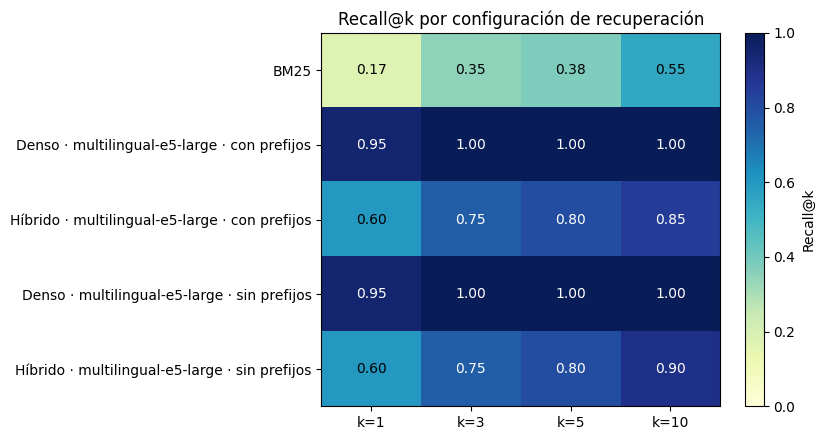

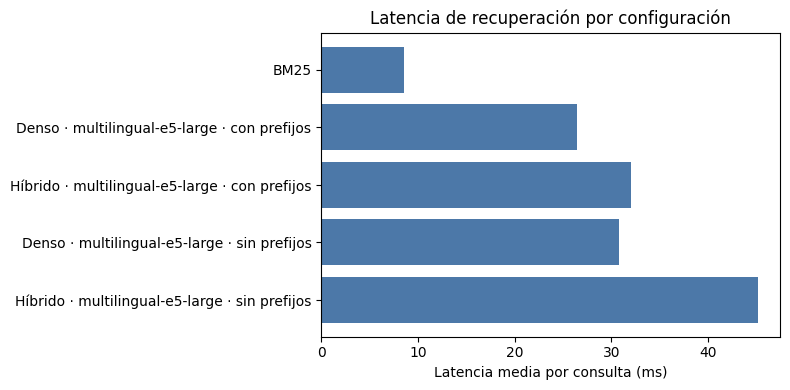

In [ ]:
mapa_calor_recall(tabla_recuperacion)
plt.show()
barras_latencia(tabla_recuperacion)
plt.show()

In [ ]:
# Recall@5 de la mejor configuración, por tipo de pregunta
detalle = detalles_recuperacion[mejor_config]
detalle.groupby("tipo")["rango"].agg(preguntas="size", **{"recall@5": lambda r: (r <= 5).mean(),
                                                           "mrr": lambda r: (1 / r).fillna(0).mean()}).round(3)

,preguntas,recall@5,mrr
tipo,,,
alineacion,6,1.0,0.917
cambio,8,1.0,0.938
entrenador,6,1.0,1.000
marcador,14,1.0,1.000
plantilla,6,1.0,1.000


In [ ]:
# Respuestas incorrectas de la configuración con RAG de mayor k, para analizarlas caso por caso
config_k = tabla_generacion["config"].iloc[-1]
errores = detalles_generacion[config_k].query("not acierta")[["tipo", "pregunta", "esperado", "respuesta", "gold_en_contexto"]]
print(f"{config_k}: {len(errores)} respuestas incorrectas")
errores.head(8)

Con RAG · k=10: 5 respuestas incorrectas


,tipo,pregunta,esperado,respuesta,gold_en_contexto
6,marcador,¿Cuál fue el marcador de Camerún contra Países...,"(1, 2)",No tengo información sobre el marcador de Came...,True
16,cambio,¿Quién entró por Darwin Núñez en el partido Gh...,Agustín Canobbio,En el partido Ghana–Uruguay del Mundial de 202...,True
17,cambio,¿Quién entró por Gaku Shibasaki en el partido ...,Hotaru Yamaguchi,Nacer Chadli.,True
18,cambio,¿Quién entró por Josef Hickersberger en el par...,Heribert Weber,No tengo información sobre el cambio de jugado...,True
20,cambio,¿Quién entró por Bruce Rioch en el partido Per...,Archie Gemmill,No tengo información sobre el partido Perú–Esc...,True


In [ ]:
# Respuestas a las preguntas de titulares y qué fracción de los nombres del registro contienen
detalles_generacion[f"{config_k} · titulares"][["pregunta", "cobertura", "gold_en_contexto", "respuesta"]]

,pregunta,cobertura,gold_en_contexto,respuesta
0,¿Quiénes fueron los titulares de Brasil contra...,0.818182,True,En el partido del Mundial 2014 entre Brasil y ...
1,¿Quiénes fueron los titulares de Estados Unido...,0.000000,True,No tengo información sobre el partido entre Es...
2,¿Quiénes fueron los titulares de España contra...,0.000000,True,No tengo información sobre el partido entre Es...
3,¿Quiénes fueron los titulares de Yugoslavia co...,0.909091,True,En el partido del Mundial de 1974 entre Yugosl...
4,¿Quiénes fueron los titulares de Ghana contra ...,0.000000,True,No tengo información sobre el partido del Mund...
5,¿Quiénes fueron los titulares de Austria contr...,0.909091,True,En el partido del Mundial de 1982 entre Austri...


**Análisis de resultados.** En recuperación, el modelo denso es el mejor método en los tres conjuntos de preguntas (en el del grupo Quebec empata
con el híbrido). Con las
40 generadas logra Recall@1 de 0,95 y Recall@3 de 1,00 (MRR de 0,975); el híbrido queda en 0,60 de Recall@1 y entre 0,85 y
0,90 de Recall@10, y BM25 en 0,175 y 0,55. La fusión con BM25 no mejora al denso, y puede deberse a que el ranking léxico
distingue poco entre partidos con el mismo formato. Los prefijos de e5 no cambian el resultado con las 40 preguntas; en el
conjunto de ejemplo, el MRR es 1,00 con prefijos y 0,917 sin ellos, por una sola pregunta en segundo lugar. Como el denso
con y sin prefijos empata en MRR, `idxmax` toma el primero, el que usa prefijos. Por tipo de pregunta, el fragmento
correcto queda entre los cinco primeros en todos los casos; el MRR más bajo es el de alineaciones (0,917) y cambios (0,938).

En generación, el contexto recuperado eleva la exactitud en datos directos de 0,357 a un rango de 0,786 a 0,821, y la
abstención fuera de dominio de 0,2 a 0,9. Entre k = 3, 5 y 10 la diferencia es de una pregunta sobre 28, mientras la
latencia pasa de 0,95 a 1,98 s, así que no se observa ventaja en traer más fragmentos. La abstención indebida baja de 0,179
a 0,107 (3 de 28). Con k = 10, los cinco errores de exactitud tenían el fragmento correcto en el contexto: tres son
abstenciones y dos, un nombre equivocado. La cobertura de titulares es de 0,273 sin RAG y de 0,485, 0,667 y 0,439 con
k = 3, 5 y 10; con k = 10, tres de las seis preguntas de titulares reciben una abstención y las otras tres cubren 9 o 10 de
los 11 nombres. En el conjunto de ejemplo (6 preguntas directas) la exactitud pasa de 0,167 a un rango de 0,667 a 0,833, y
en el del grupo Quebec (4) de 0,50 a un rango de 0,50 a 0,75, sin una diferencia clara con tan pocas preguntas. No hubo
errores del servidor ni timeouts (`n_errores` = 0).

## 9. Demos

Se prueban los tipos de pregunta del caso de uso con el recuperador de mejor MRR: dato directo, alineación, resultado
histórico, plantilla, cambio, contexto, un seguimiento y una pregunta fuera de dominio. Las respuestas se imprimen tal como
las genera el modelo, sin edición.

In [ ]:
PREGUNTAS_DEMO = [
    "¿Cuál fue el marcador de Brasil contra Croacia en 2014?",
    "¿Quiénes fueron titulares de Colombia contra Uruguay en 1962?",
    "¿Cómo terminó Colombia contra la Unión Soviética en 1962?",
    "¿Qué jugadores convocó Colombia en 2014?",
    "¿Quién entró por Giovanni en el Brasil–Escocia de 1998?",
    "¿Por qué se recuerda el 4-4 de Colombia contra la URSS en 1962?",
    "¿Quién ganó el último Roland Garros?",
    "¿Quién ganó el mundial de 2026?",
]
asegura_ollama()
chat_demo = ChatMundial(recuperador_mejor, llm, k=5)
for pregunta in PREGUNTAS_DEMO[:2] if SMOKE_TEST else PREGUNTAS_DEMO:
    chat_demo.reiniciar()
    r = chat_demo.preguntar(pregunta)
    print(f"Pregunta: {pregunta}\nRespuesta: {r.texto}")
    print("Fuentes: " + " | ".join(f"[{i}] {etiqueta_fuente(d)}" for i, d in enumerate(r.docs, 1)) + "\n")

Pregunta: ¿Cuál fue el marcador de Brasil contra Croacia en 2014?
Respuesta: En el partido del Mundial 2014, el marcador final fue 3-1 a favor de Brasil.
Fuentes: [1] Partido · Mundial 2014 · Group A · Brazil vs Croatia (wikipedia/2014.txt:9; 2014--brazil/cup.txt:36) | [2] Partido · Mundial 2014 · Semi-finals · Brazil vs Germany (wikipedia/2014.txt:930; 2014--brazil/cup_finals.txt:65) | [3] Partido · Mundial 2022 · Quarter-finals · Croatia vs Brazil (wikipedia/2022.txt:921; 2022--qatar/cup_finals.txt:39) | [4] Partido · Mundial 2014 · Group A · Cameroon vs Croatia (wikipedia/2014.txt:300; 2014--brazil/cup.txt:45) | [5] Wikipedia · Fase de grupos (https://es.wikipedia.org/wiki/Copa_Mundial_de_Fútbol_de_2014, descargado el 2026-10-05)

Pregunta: ¿Quiénes fueron titulares de Colombia contra Uruguay en 1962?
Respuesta: No tengo información sobre los titulares de Colombia contra Uruguay en el partido del Mundial 1962.
Fuentes: [1] Partido · Mundial 1962 · Group 1 · Uruguay vs Colombia (wiki

In [ ]:
# Conversación con seguimiento: la segunda pregunta solo se entiende con la memoria
asegura_ollama()
chat_demo.reiniciar()
for pregunta in ["¿Cómo terminó Colombia contra la Unión Soviética en 1962?", "¿Y quiénes marcaron los goles?"]:
    r = chat_demo.preguntar(pregunta)
    print(f"Pregunta: {pregunta}\nReformulación cruda: {r.reformulacion!r}\nConsulta usada para recuperar ({r.origen}): {r.consulta}\nRespuesta: {r.texto}\n")

Pregunta: ¿Cómo terminó Colombia contra la Unión Soviética en 1962?
Reformulación cruda: None
Consulta usada para recuperar (original): ¿Cómo terminó Colombia contra la Unión Soviética en 1962?
Respuesta: Colombia empató 4-4 con la Unión Soviética en el partido del Grupo 1 del Mundial de Fútbol de 1962, que se jugó el 3 de junio de 1962 en el Estadio Carlos Dittborn de Arica, Chile.

Pregunta: ¿Y quiénes marcaron los goles?
Reformulación cruda: 'No tengo información sobre los goles específicos de ese partido.'
Consulta usada para recuperar (unida): ¿Cómo terminó Colombia contra la Unión Soviética en 1962? ¿Y quiénes marcaron los goles?
Respuesta: En el partido del Mundial 1962 entre Colombia y Uruguay, los goles fueron anotados por:

* Francisco Zuluaga (Colombia) en el minuto 19' (p)
* Luis Cubilla (Uruguay) en el minuto 56'
* José Sasía (Uruguay) en el minuto 75'



### Conversaciones candidatas de seguimiento

La demo anterior se deja como evidencia de un fallo. Estas conversaciones de dos turnos se prueban para ver en cuáles la
memoria sí funciona. Cada una se ejecuta dos veces, reiniciando el chat entre ejecuciones, y se imprime la reformulación
cruda, la consulta usada y su origen, las fuentes recuperadas y la respuesta.

In [ ]:
asegura_ollama()
CONVERSACIONES_CANDIDATAS = [
    ("¿Cuál fue el marcador de Brasil contra Croacia en 2014?", "¿Y quiénes marcaron los goles?"),
    ("¿Cuál fue el marcador de Brasil contra Croacia en 2014?", "¿Y en qué estadio se jugó?"),
    ("¿Quién entró por Giovanni en el Brasil–Escocia de 1998?", "¿Y en qué minuto fue el cambio?"),
]
for primera, segunda in CONVERSACIONES_CANDIDATAS:
    for ejecucion in (1, 2):
        chat_demo.reiniciar()
        print(f"=== {primera} -> {segunda} (ejecución {ejecucion})")
        for pregunta in (primera, segunda):
            r = chat_demo.preguntar(pregunta)
            print(f"Pregunta: {pregunta}")
            print(f"Reformulación cruda: {r.reformulacion!r}")
            print(f"Consulta usada ({r.origen}): {r.consulta}")
            print("Fuentes: " + " | ".join(f"[{i}] {etiqueta_fuente(d)}" for i, d in enumerate(r.docs, 1)))
            print(f"Respuesta: {r.texto}")
            print()

=== ¿Cuál fue el marcador de Brasil contra Croacia en 2014? -> ¿Y quiénes marcaron los goles? (ejecución 1)
Pregunta: ¿Cuál fue el marcador de Brasil contra Croacia en 2014?
Reformulación cruda: None
Consulta usada (original): ¿Cuál fue el marcador de Brasil contra Croacia en 2014?
Fuentes: [1] Partido · Mundial 2014 · Group A · Brazil vs Croatia (wikipedia/2014.txt:9; 2014--brazil/cup.txt:36) | [2] Partido · Mundial 2014 · Semi-finals · Brazil vs Germany (wikipedia/2014.txt:930; 2014--brazil/cup_finals.txt:65) | [3] Partido · Mundial 2022 · Quarter-finals · Croatia vs Brazil (wikipedia/2022.txt:921; 2022--qatar/cup_finals.txt:39) | [4] Partido · Mundial 2014 · Group A · Cameroon vs Croatia (wikipedia/2014.txt:300; 2014--brazil/cup.txt:45) | [5] Wikipedia · Fase de grupos (https://es.wikipedia.org/wiki/Copa_Mundial_de_Fútbol_de_2014, descargado el 2026-10-05)
Respuesta: En el partido del Mundial 2014, el marcador final fue 3-1 a favor de Brasil.

Pregunta: ¿Y quiénes marcaron los goles

### Preguntas de agregación

Estas dos preguntas exigen contar o comparar sobre muchos partidos, no leer un fragmento. El recuperador entrega solo los k
fragmentos más cercanos, así que la respuesta correcta no cabe en el contexto. Se muestran para documentar la limitación;
no se calculan métricas y las respuestas se leen a mano.

In [ ]:
asegura_ollama()
PREGUNTAS_AGREGACION = ["¿En cuántos mundiales ha participado Colombia?", "¿Qué países han disputado más finales?"]
for pregunta in PREGUNTAS_AGREGACION:
    chat_demo.reiniciar()
    r = chat_demo.preguntar(pregunta)
    print(f"Pregunta: {pregunta}\nRespuesta: {r.texto}")
    print("Fuentes: " + " | ".join(f"[{i}] {etiqueta_fuente(d)}" for i, d in enumerate(r.docs, 1)) + "\n")

Pregunta: ¿En cuántos mundiales ha participado Colombia?
Respuesta: Colombia ha participado en siete Copas Mundiales de Fútbol: 1962, 1990, 1994, 1998, 2014, 2018 y 2026.
Fuentes: [1] Wikipedia · Introducción (https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Colombia, descargado el 2026-10-05) | [2] Wikipedia · Dirección técnica actual (https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Colombia, descargado el 2026-10-05) | [3] Wikipedia · Finales disputadas (https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Colombia, descargado el 2026-10-05) | [4] Wikipedia · Selección femenina de fútbol de Colombia (https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Colombia, descargado el 2026-10-05) | [5] Wikipedia · Selección femenina de fútbol de Colombia (https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Colombia, descargado el 2026-10-05)

Pregunta: ¿Qué países han disputado más finales?
Respuesta: No tengo información sobre el número de finales disputados por países en la Copa M

**Análisis de las demos.** Con el índice completo se responden bien el marcador de Brasil contra Croacia (3-1), el 4-4 de
Colombia contra la Unión Soviética, el cambio de Giovanni por Leonardo y la plantilla de Colombia en 2014, siempre con el
fragmento correcto en el primer lugar. La pregunta sobre Roland Garros recibe una abstención. La del Mundial de 2026 se
responde con España 1-0 Argentina en tiempo extra, que coincide con el fragmento de la final recuperado en tercer lugar;
como los datos de 2026 se verificaron solo en parte, esa respuesta se toma con cautela.

Hay tres fallos. Los titulares de Colombia contra Uruguay en 1962 reciben una abstención aunque el partido era el primer
fragmento recuperado. «¿Por qué se recuerda el 4-4?» se contesta de forma incompleta: la respuesta habla de un único gol
olímpico, sin mencionar a Marcos Coll ni la remontada de Colombia, datos que sí figuran en el artículo de la selección. Y el
seguimiento «¿Y quiénes marcaron los goles?» falla: la reformulación del modelo fue una negativa, se usó la unión de
preguntas y la respuesta enumeró los goles de Uruguay–Colombia (Zuluaga, Cubilla y Sasía) en lugar de los del 4-4.

En las conversaciones candidatas, la reformulación del modelo fue en dos de las tres una respuesta inventada y no una
pregunta («Fred, David Luiz y Oscar»; «Estadio Castelão, en Fortaleza»), que luego se usó como consulta. En la primera
llevó a responder con goles de Brasil–Colombia. En la segunda, el fragmento correcto igualmente quedó primero y la
respuesta (Arena Corinthians, São Paulo) coincide con el registro. En la tercera, la reformulación fue una negativa, entró
el respaldo y la respuesta fue correcta (minuto 46). Las dos ejecuciones de cada conversación dieron lo mismo.

En agregación, «siete Mundiales» para Colombia es correcto y la primera fuente recuperada, la introducción del artículo de
la selección, trae esa cifra escrita; no hubo conteo. Sobre las finales, el modelo se abstiene.

### Interfaz

La interfaz muestra la respuesta y, en un acordeón, cada fragmento recuperado con su fuente. Se lanza con el
recuperador de mejor MRR. El lanzamiento no bloquea la celda: la interfaz sigue activa mientras el entorno esté en
ejecución, y al ejecutar todo el notebook de corrido no debe cerrarse en la celda siguiente. Para cerrarla al terminar,
se ejecuta `demo.close()`.

In [ ]:
asegura_ollama()
demo = crea_interfaz(ChatMundial(recuperador_mejor, llm, k=5))
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ef2b372705a6bf1d48.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Ejecutar esta celda solo al terminar de usar la interfaz (cierra el servidor y el enlace público).
# demo.close()

Closing server running on port: 7860


## 10. Conclusiones y limitaciones

**Conclusiones.** Con la ejecución completa sobre T4 se puede ver que:

- La recuperación densa con e5-large es la opción más confiable. Con las 40 preguntas generadas deja el fragmento correcto
  en el primer lugar en el 95 % de los casos y entre los tres primeros en todos. BM25 queda por debajo en los tres
  conjuntos y el híbrido en dos de ellos, y los prefijos de e5 casi no influyen.
- Dar contexto al modelo cambia el resultado: la exactitud en datos directos pasa de 0,357 sin RAG a un rango de 0,786 a
  0,821, y la abstención fuera de dominio, de 0,2 a 0,9. Subir k de 3 a 10 no mejora la exactitud y duplica la latencia
  (de 0,95 a 1,98 s).
- Los errores que quedan están en la generación y no en la recuperación. Con k = 10, los cinco errores de exactitud tenían
  el fragmento correcto en el contexto, y varias alineaciones reciben una abstención pese a tenerlo.
- La memoria conversacional funciona de forma irregular. El modelo de 3B suele responder en lugar de reformular, y el
  respaldo por unión de preguntas se usó en dos casos y resolvió uno.
- Las cifras son optimistas: las 40 preguntas siguen plantillas, y los conjuntos de ejemplo (8 preguntas) y del grupo Quebec
  (5) son demasiado pequeños para estimar porcentajes. Aun así, en los tres BM25 queda último y el denso primero o
  empatado.

**Errores observados en la ejecución completa**

- *Abstención con el dato en el contexto.* Con k = 10, tres de los cinco errores de exactitud son respuestas «No tengo
  información…» (un marcador y dos cambios) con el fragmento correcto en el contexto; los otros dos son nombres equivocados
  («Nicolás de la Cruz» en lugar de Agustín Canobbio y «Nacer Chadli» en lugar de Hotaru Yamaguchi). En las alineaciones, tres de las seis preguntas reciben una
  abstención, y en la demo ocurre con los titulares de Colombia contra Uruguay en 1962, cuyo partido era el primer fragmento
  recuperado. El fallo está en la generación y no en la recuperación.
- *Seguimiento del 4-4.* Ante «¿Y quiénes marcaron los goles?» tras la pregunta sobre Colombia–URSS, la reformulación cruda
  del modelo fue «No tengo información sobre los goles específicos de ese partido.», se activó la unión de preguntas y la
  respuesta enumeró los goles de Uruguay–Colombia (Zuluaga, Cubilla y Sasía) en lugar de los del 4-4 (Ivanov, Chislenko,
  Ponedelnik, Aceros, Coll, Rada y Klinger). La demo se deja tal cual como evidencia.
- *«¿Por qué se recuerda el 4-4?».* La respuesta es incompleta: menciona un único gol olímpico sin nombrar a Marcos Coll y
  omite la remontada, que según el artículo descargado fue desde 1-3 al descanso y 1-4 al inicio del segundo tiempo.
- *Agregación.* «¿En cuántos mundiales ha participado Colombia?» se respondió bien (siete), pero porque la introducción del
  artículo de la selección, que quedó entre las fuentes, trae la frase escrita, no porque se hayan contado ediciones. «¿Qué
  países han disputado más finales?» recibió una abstención, y los fragmentos recuperados no permiten contarlas.

**Limitaciones del diseño y de los datos**

- Las 40 preguntas de evaluación salen de cinco plantillas y repiten las palabras del fragmento, por lo que los números
  sobre ellas son optimistas respecto a preguntas reales. Los conjuntos de ejemplo y del grupo Quebec son
  pequeños y también tienen sus límites: sus resultados se reportan aparte y no se mezclan.
- Las preguntas de agregación (contar mundiales, comparar finales) no se resuelven con el contexto de k fragmentos; se
  documentan en las demos sin métricas.
- La abstención se detecta con una expresión regular, que puede confundir una respuesta con una negativa, o al revés.
  Se complementa con la abstención indebida, pero no sustituye la revisión manual de las respuestas.
- El recuperador usado en generación se eligió con las mismas 40 preguntas generadas; el sesgo es pequeño con tres métodos,
  y el conjunto de ejemplo no participó en esa elección.
- Un modelo de 3B parámetros es más propenso a errores con cifras y no está pensado para sumar o contar entre partidos
  (por ejemplo, los goles de un jugador en un Mundial). Por eso la evaluación se limita a datos directos.
- Si el recuperador trae el partido equivocado, el modelo puede responder con seguridad algo erróneo. Casi todos los
  fragmentos de partido comparten formato, lo que dificulta distinguirlos y motiva el enfoque híbrido.
- Las preguntas están en español y los datos en inglés; los nombres de selecciones y las tildes difieren entre fuentes. Se
  normalizaron con un diccionario de alias y un tokenizador sin tildes, pero la normalización no es exhaustiva.
- Los datos de 2026 se contrastaron solo en parte con otras fuentes: el Grupo K y el desenlace de Colombia coinciden con
  Wikipedia y prensa, y los 72 partidos de grupos y las eliminatorias se validan por consistencia interna (tablas
  frente a cruces). No hay alineaciones de 2026.
- La validación del analizador confirma la estructura y la consistencia entre archivos, no que cada alineación o
  goleador sea correcto.
- Wikipedia cambia; el notebook trabaja con una copia con fecha de descarga y revisión.
- Licencias: el repositorio es CC0, con carpetas derivadas de Wikipedia y RSSSF; el texto de Wikipedia es CC BY-SA.
- No se implementaron los experimentos opcionales (reranker, `llama3.1:8b`, juez de fidelidad con un LLM, ajuste fino de
  embeddings), por el costo en tiempo de ejecución y por no ser necesarios para el caso.

### Tiempo de ejecución medido

La suma de las etapas cronometradas en la ejecución completa fue de 510,7 s (8,5 min) sobre una T4. Los índices de e5-large
tardaron 85 y 91 s, y la generación sobre el conjunto principal, entre 49 s (sin RAG) y 94 s (k = 10). La tabla no incluye la
instalación de dependencias, las descargas de datos y modelos ni el análisis exploratorio. Por eso, lo medido queda muy por
debajo del objetivo de 30 minutos desde cero, pero el tiempo de punta a punta no se puede confirmar con estos datos.

In [ ]:
crono.resumen().round(1)

,etapa,segundos,minutos
0,Ollama: arranque y descarga del modelo,31.8,0.5
1,índice multilingual-e5-large · con prefijos,85.3,1.4
2,BM25: tokenizar corpus,0.3,0.0
3,evaluar BM25,0.4,0.0
4,evaluar Denso · multilingual-e5-large · con pr...,1.1,0.0
5,evaluar Híbrido · multilingual-e5-large · con ...,1.4,0.0
6,índice multilingual-e5-large · sin prefijos,91.1,1.5
7,evaluar Denso · multilingual-e5-large · sin pr...,1.3,0.0
8,evaluar Híbrido · multilingual-e5-large · sin ...,1.9,0.0
9,generar Sin RAG,48.9,0.8
